# Évaluation des modèles

CSI 4506 - automne 2026

Marcel Turcotte  
Version: sept. 24, 2026 18h03

# Préambule

## Message du jour

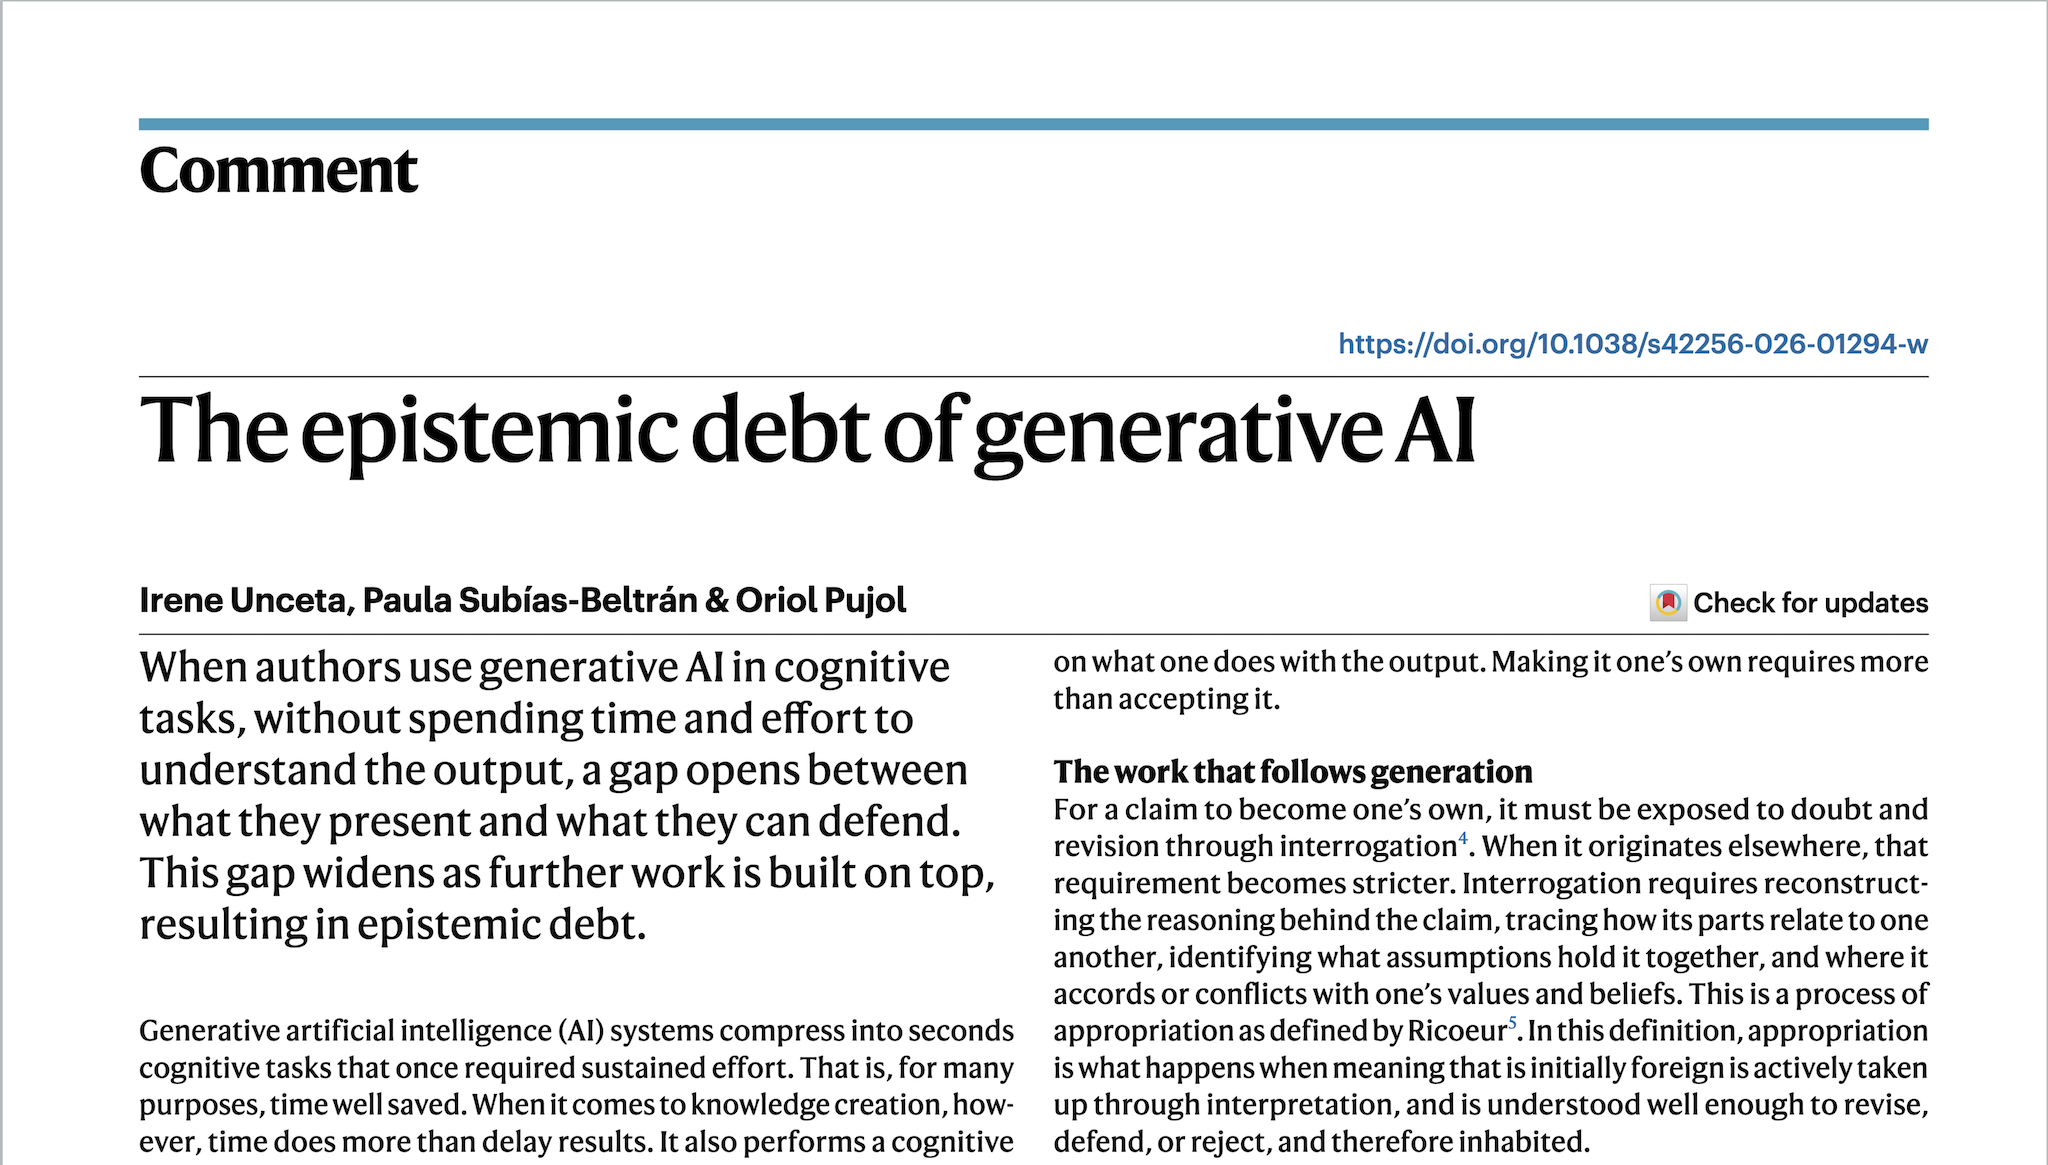

Unceta et al. (2026),
<a href="https://www.nature.com/articles/s42256-026-01294-w"
class="external"
data-icon="true">www.nature.com/articles/s42256-026-01294-w</a>

>  **(Unceta et al. 2026)**
>
> Lorsque des auteurs utilisent l’intelligence artificielle générative
> (*generative AI*) pour des tâches cognitives sans consacrer le temps
> et les efforts nécessaires à comprendre le résultat, un écart se
> creuse entre ce qu’ils présentent et ce qu’ils sont capables de
> défendre. Cet écart s’élargit lorsque des travaux ultérieurs
> s’appuient sur les premiers résultats, ce qui crée une **dette
> épistémique** (*epistemic debt*).

L’article est accessible intégralement à partir d’une adresse IP de
l’Université d’Ottawa.

## Aperçu du cours

Ce cours développe l’**évaluation de la classification** à partir de la
**matrice de confusion**. Il introduit l’**exactitude**, la
**précision**, le **rappel** et le **score $F_1$**, puis examine le
**déséquilibre des classes** et les moyennes **micro** et **macro**. Les
dernières sections relient les **seuils de décision** aux courbes
**précision-rappel** et **ROC**, puis interprètent l’**AUROC** comme une
mesure de la qualité du classement.

## Résultats d’apprentissage

- **Déduire** les dénombrements binaires et un-contre-tous à partir
  d’une matrice de confusion.
- **Calculer** et **interpréter** l’exactitude, la précision, le rappel
  et le score $F_1$.
- **Expliquer** pourquoi le déséquilibre des classes peut rendre
  l’exactitude trompeuse.
- **Comparer** les moyennes micro et macro pour les métriques
  multiclasses.
- **Relier** un seuil de décision à la précision, au rappel et à un
  point de fonctionnement ROC.
- **Construire** une courbe ROC à partir des scores d’un classificateur
  et **interpréter** l’AUROC comme une mesure du classement.

# Mesures de performance

## Matrice de confusion

|                        | **Positif** (**Prédit**) | **Négatif** (**Prédit**) |
|------------------------|------------------------|------------------------|
| **Positif** (**Réel**) | Vrai positif (VP)        | Faux négatif (FN)        |
| **Négatif** (**Réel**) | Faux positif (FP)        | Vrai négatif (VN)        |

Une **matrice de confusion** est un tableau résumant la performance d’un
algorithme de classification (ici pour une tâche de classification
binaire).

- Dans l’analyse statistique, les **faux positifs (FP)** sont
  communément appelés **erreurs de type I**, et les **faux négatifs
  (FN)** sont connus sous le nom d’**erreurs de type II**.
- Les éléments de la diagonale représentent les résultats correctement
  prédits, à savoir les vrais positifs (VP) et les vrais négatifs (VN).
- À l’inverse, les éléments hors diagonale correspondent aux prédictions
  incorrectes, spécifiquement les faux positifs (FP) et les faux
  négatifs (FN).
- La **matrice de confusion** encapsule toutes les informations
  essentielles nécessaires pour évaluer la performance d’un modèle de
  classification.
- Bien que la matrice de confusion fournisse une vue d’ensemble, des
  **mesures plus concises** telles que l’**exactitude**, la
  **précision**, le **rappel**, et le **score F$_1$** sont souvent plus
  intuitives et pratiques pour résumer la performance du modèle.

## ConfusionMatrixDisplay

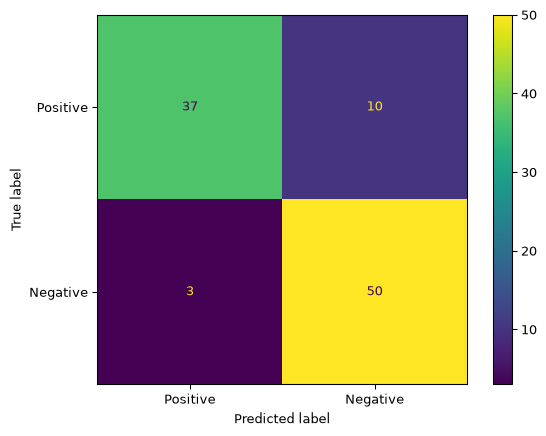

In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

seed = 42

X, y = make_classification(n_samples = 500, random_state=seed)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=0)

clf = LogisticRegression(random_state=seed)

clf.fit(X_train, y_train)

predictions = clf.predict(X_test)

cm = confusion_matrix(y_test, predictions, labels=[1, 0])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Positive", "Negative"])

disp.plot()
plt.show()

Nous utilisons la fonction `make_classification` pour générer un jeu de
données synthétique, qui est ensuite analysé à l’aide d’un modèle de
`LogisticRegression`. Pour les deux fonctions `confusion_matrix` et
`ConfusionMatrixDisplay`, nous configurons les étiquettes pour nous
assurer que la classe ‘Positive’ précède, en accord avec les données
tabulaires présentées à l’écran précédent. La matrice de confusion
résultante donne les valeurs suivantes : Vrais Positifs (VP) = 37, Faux
Négatifs (FN) = 10, Faux Positifs (FP) = 3, et Vrais Négatifs (VN) = 50.

## Matrice de confusion

Étant donné un ensemble de test avec $N$ exemples et un classificateur
$h(x) :$

$$
C_{i,j} = \sum_{k = 1}^N [y_k = i \wedge h(x_k) = j]
$$

Où $C$ est une matrice $l \times l$, pour un ensemble de données avec
$l$ classes.

Une matrice de confusion $C$ est définie de telle sorte que chaque
élément $C_{i,j}$ représente le nombre d’observations appartenant
réellement à la classe $i$ mais prédites comme appartenant à la classe
$j$.

Examinons maintenant le cas général d’une matrice de confusion avec $l$
classes, qui peut initialement sembler “confus” à comprendre.

## Matrice de confusion

- Le nombre total d’exemples de la classe (réelle) $i$ est $$
  C_{i \cdot} = \sum_{j=1}^l C_{i,j}
  $$

- Le nombre total d’exemples assignés à la classe (prédite) $j$ par le
  classificateur $h$ est $$
  C_{\cdot j} = \sum_{i=1}^l C_{i,j}
  $$

## Matrice de confusion

- Les termes sur la diagonale indiquent le nombre total d’exemples
  classés correctement par le classificateur $h$. Ainsi, le nombre
  d’exemples correctement classés est $$
  \sum_{i=1}^l C_{i,i}
  $$

- Les termes non-diagonaux représentent les erreurs de classification.

## Matrice de confusion - multi-classes

Pour évaluer la performance dans un contexte **multi-classes**, on
dérive généralement des métriques **“un-contre-tous”** pour **chaque
classe** à partir de la matrice de confusion. Ces métriques sont ensuite
**moyennées** en utilisant des schémas de pondération spécifiques.

## Matrice de confusion - multi-classes

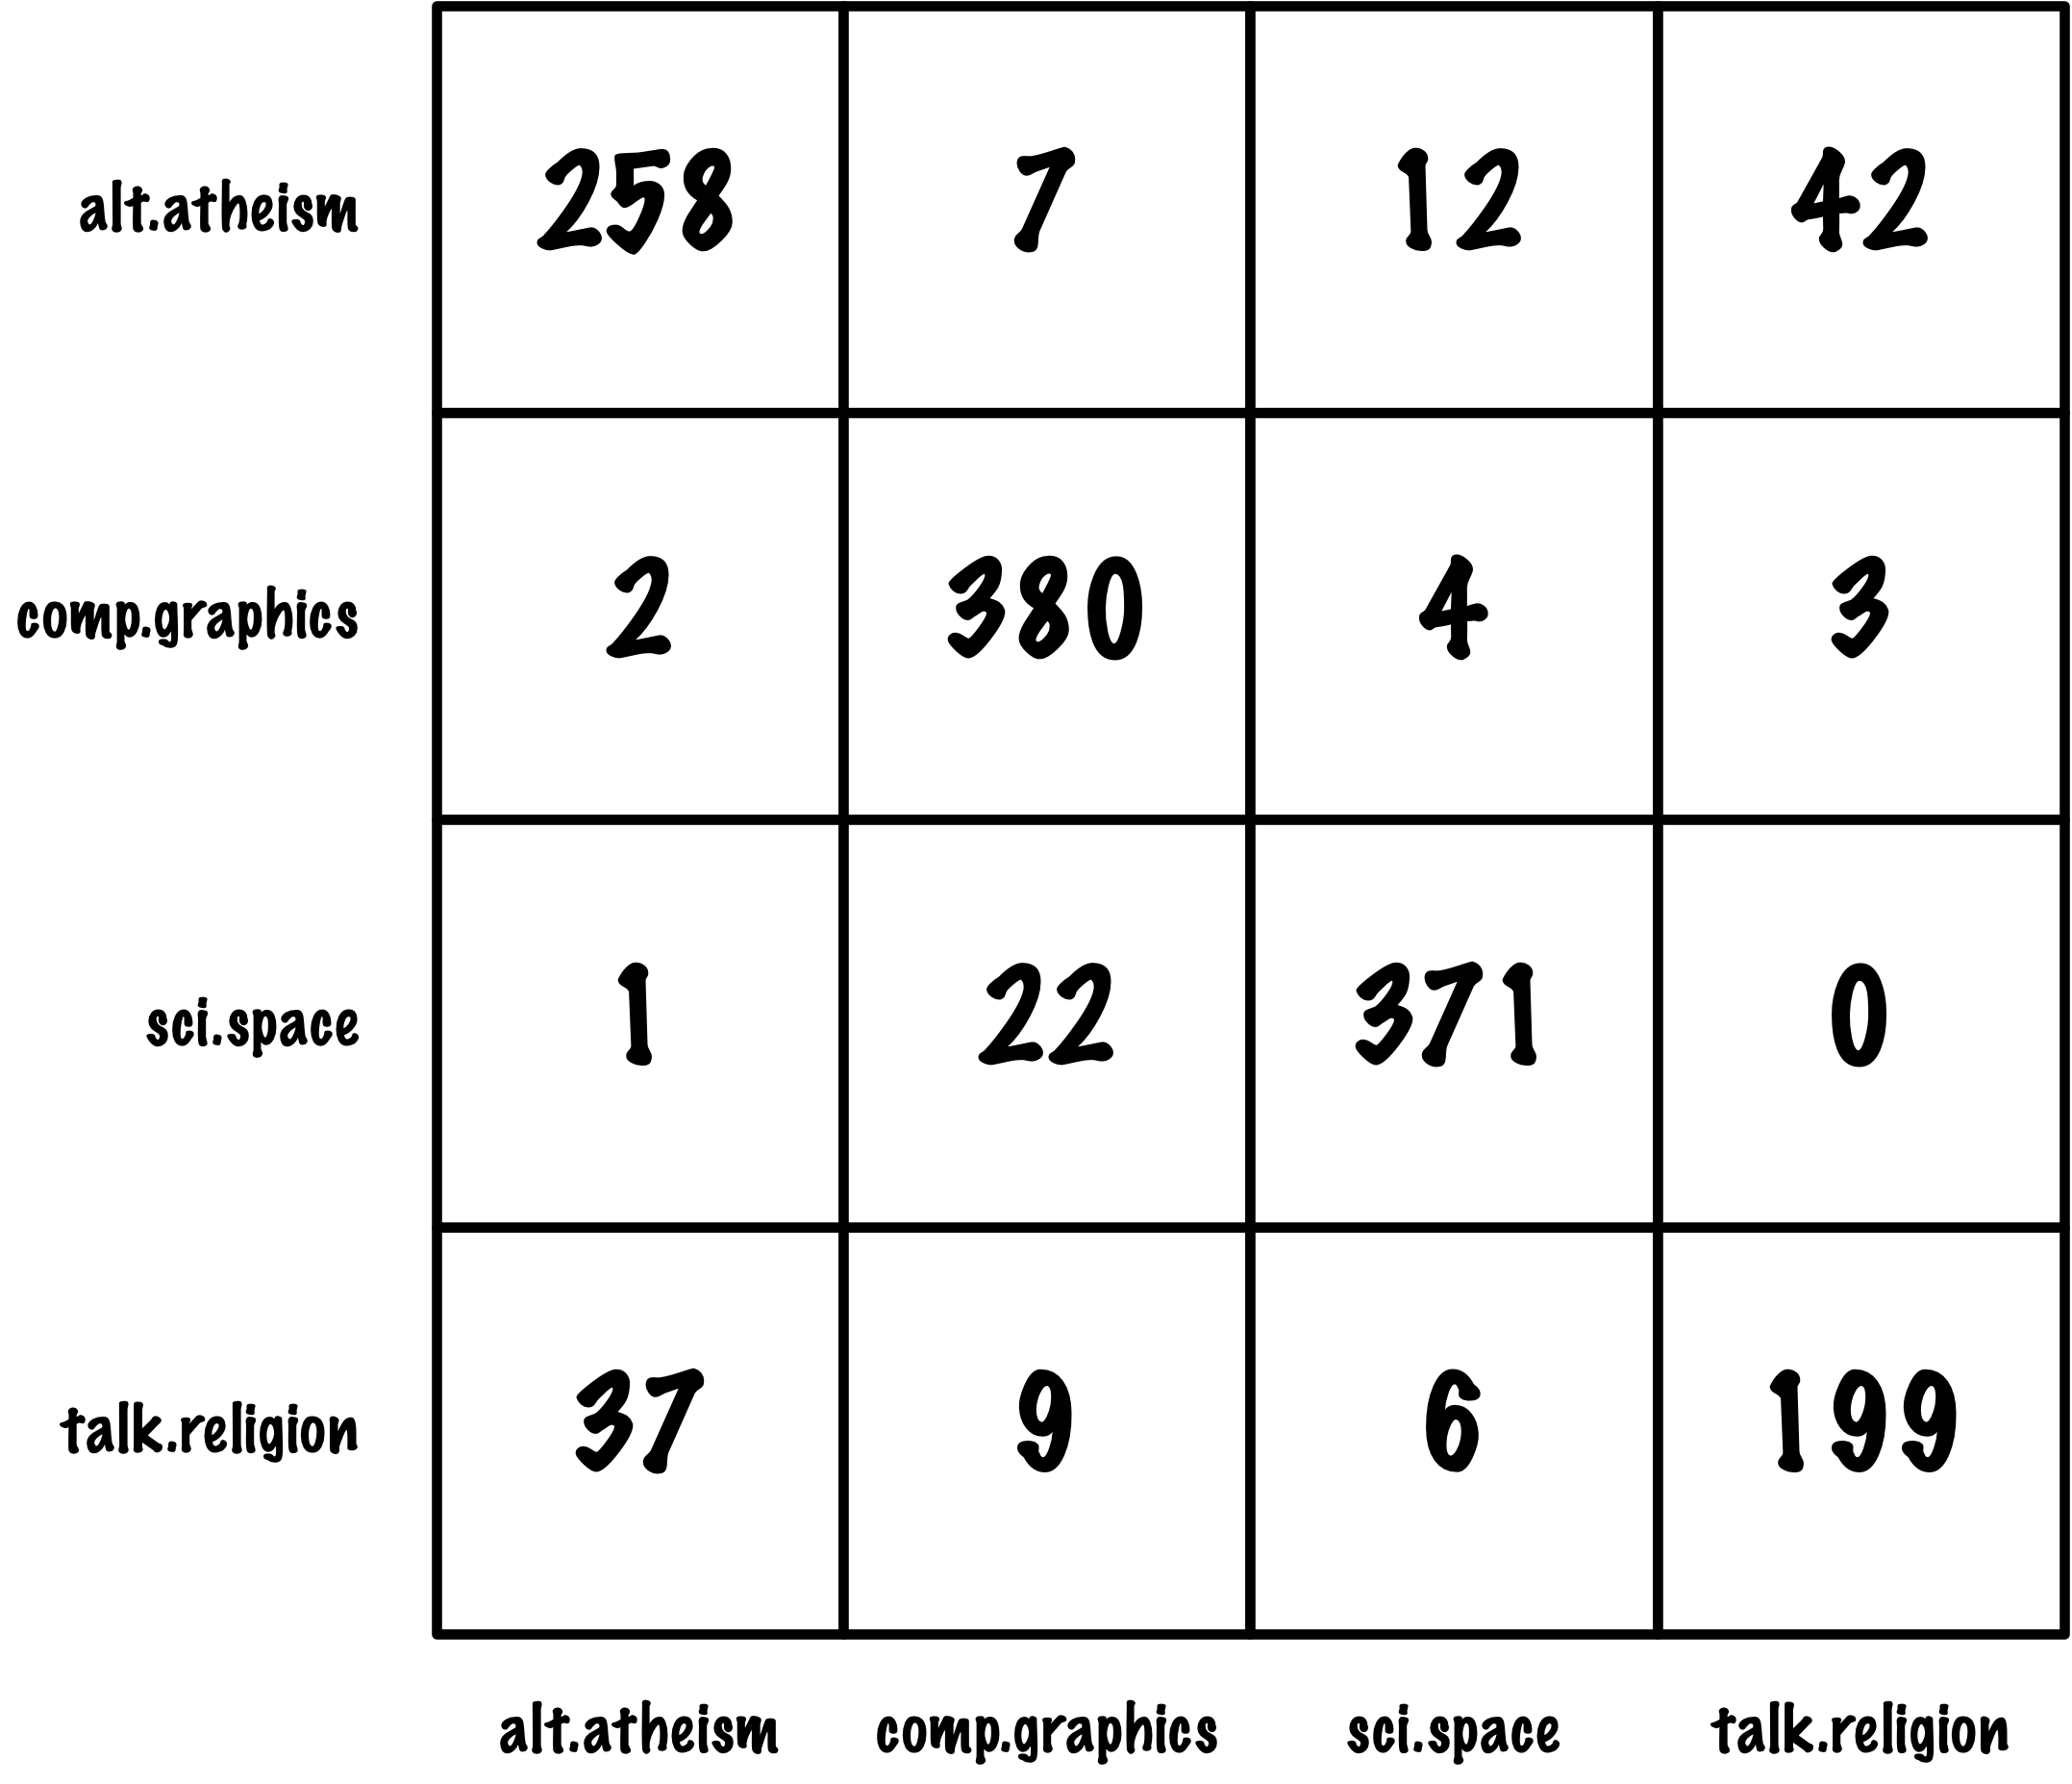

Utilisation des données du <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html#sklearn.datasets.fetch_20newsgroups"
class="external" data-icon="true">jeu de données textuel 20
Newsgroups</a> de <a href="https://scikit-learn.org" class="external"
data-icon="true">scikit-learn.org</a>.

## Matrice de confusion - vrai positif

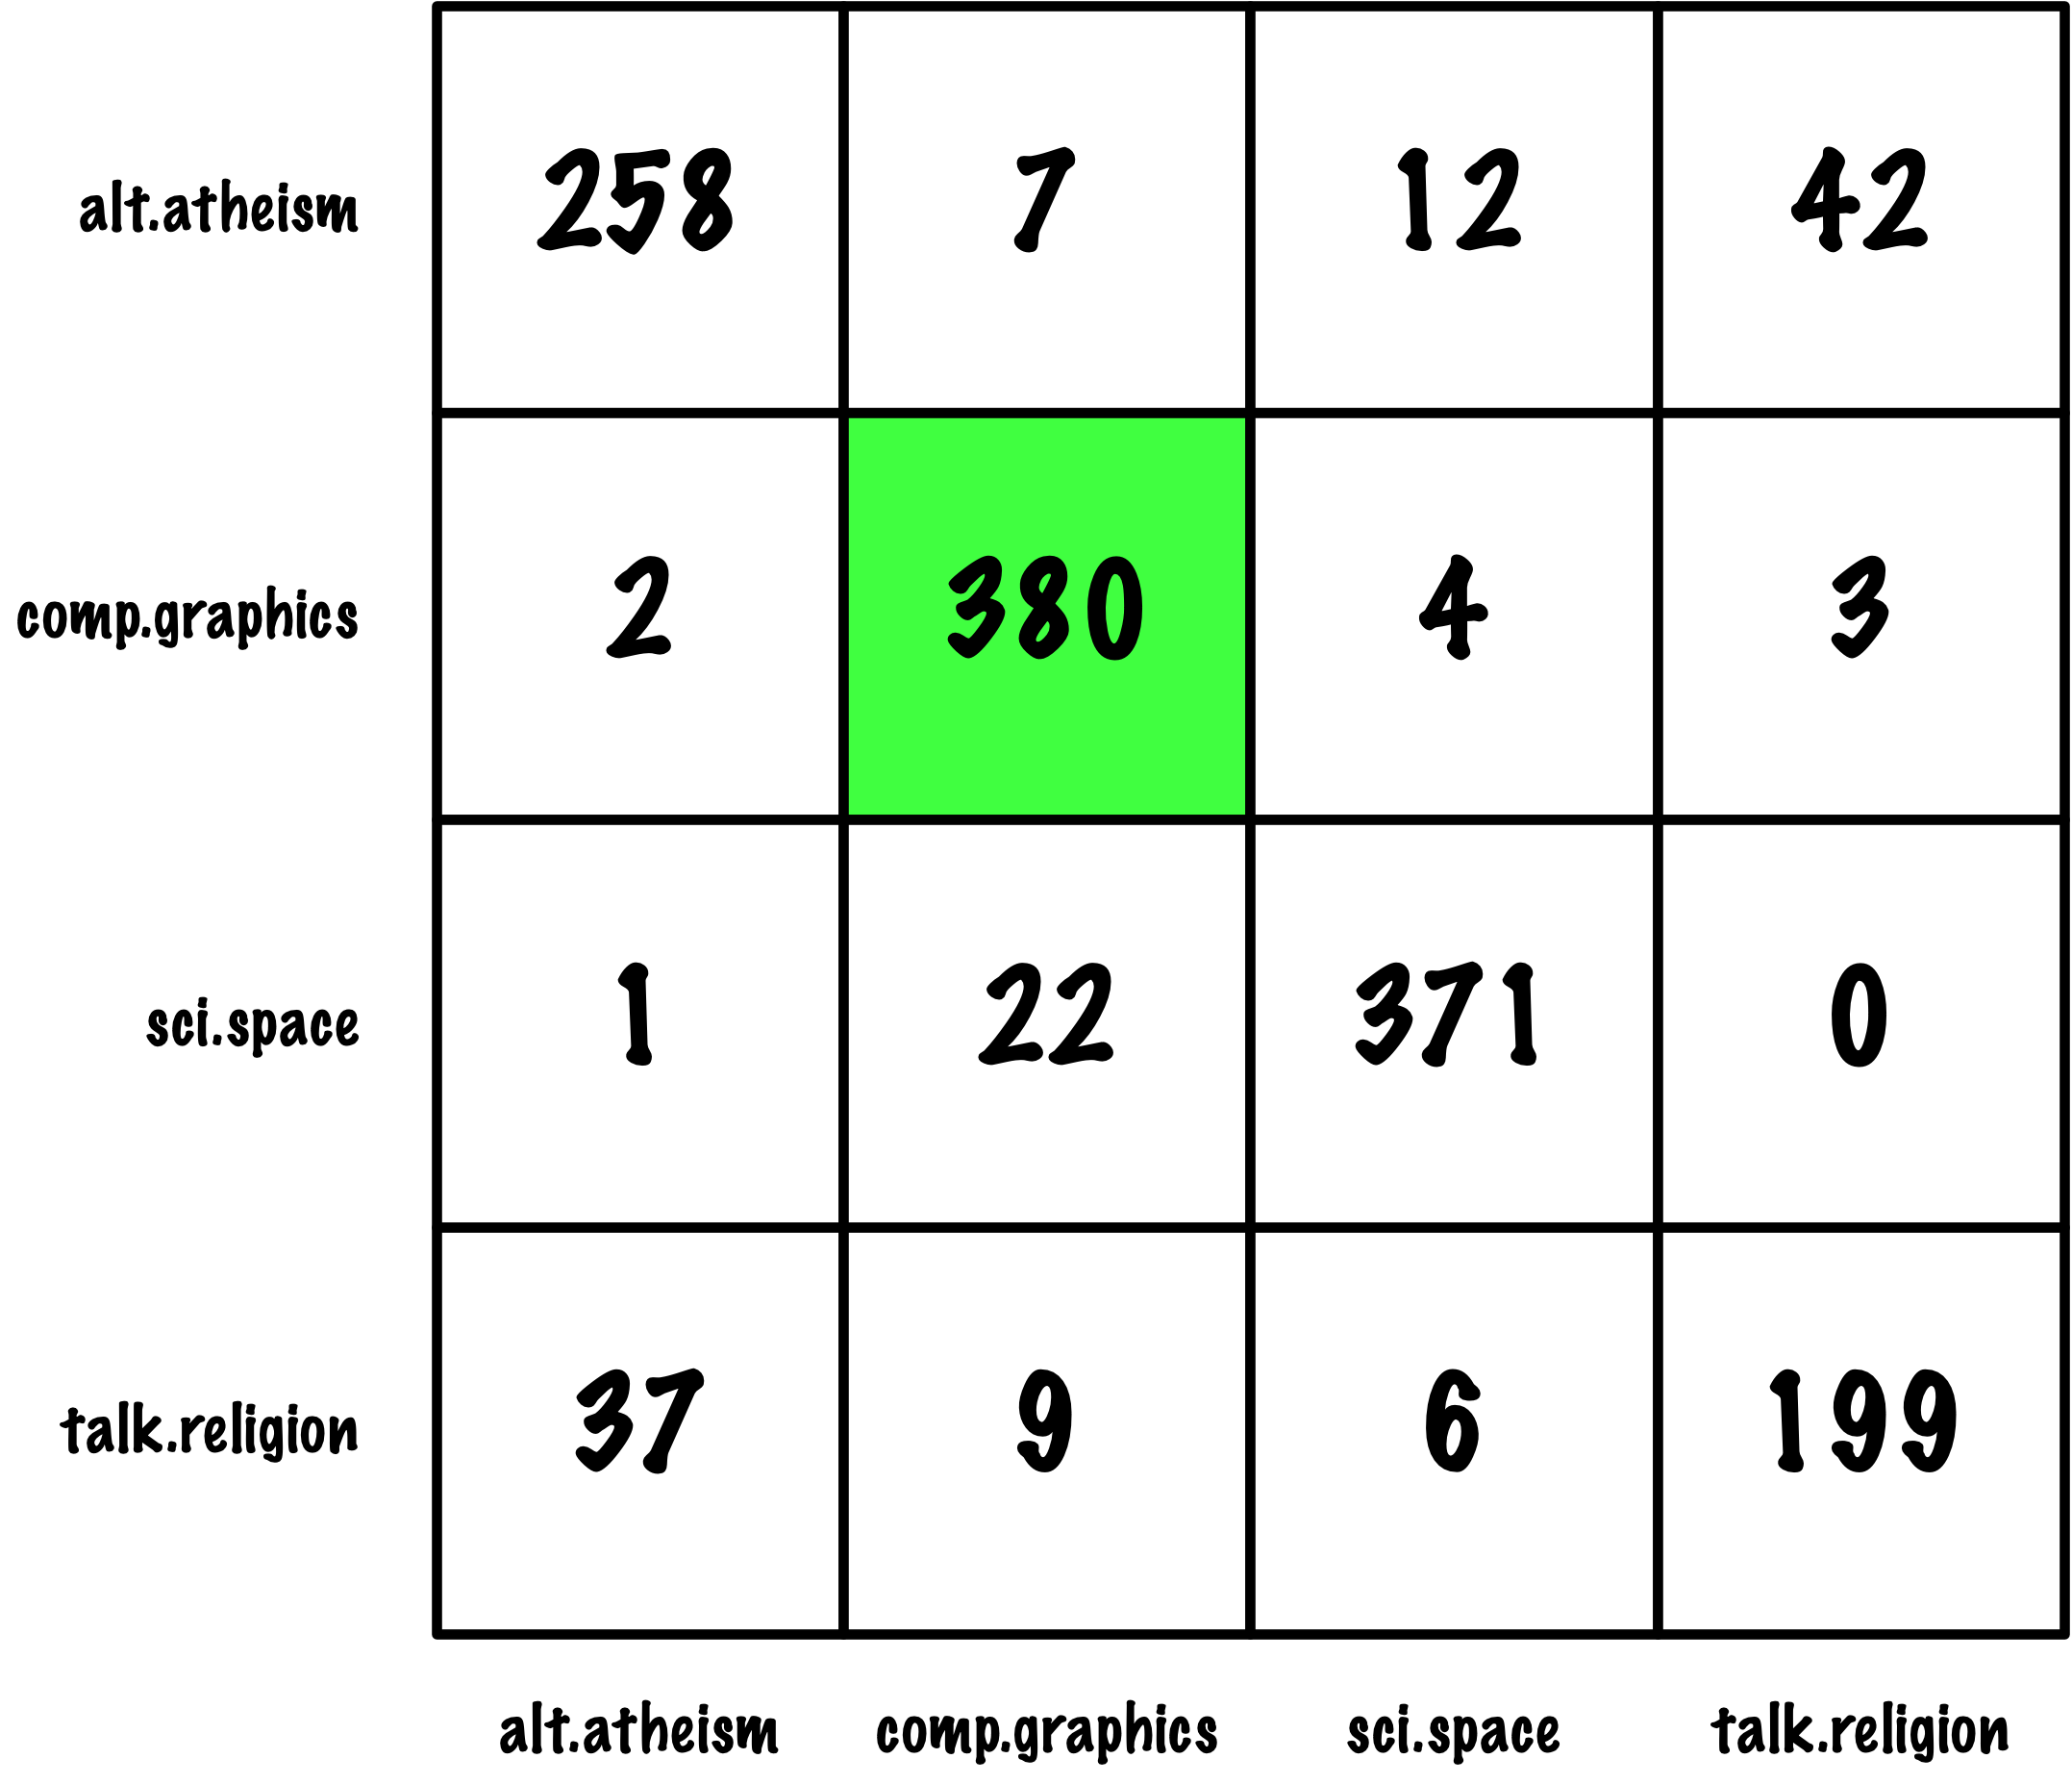

`comp.graphics` est la classe **vraie** ($i$).

## Matrice de confusion - faux positif

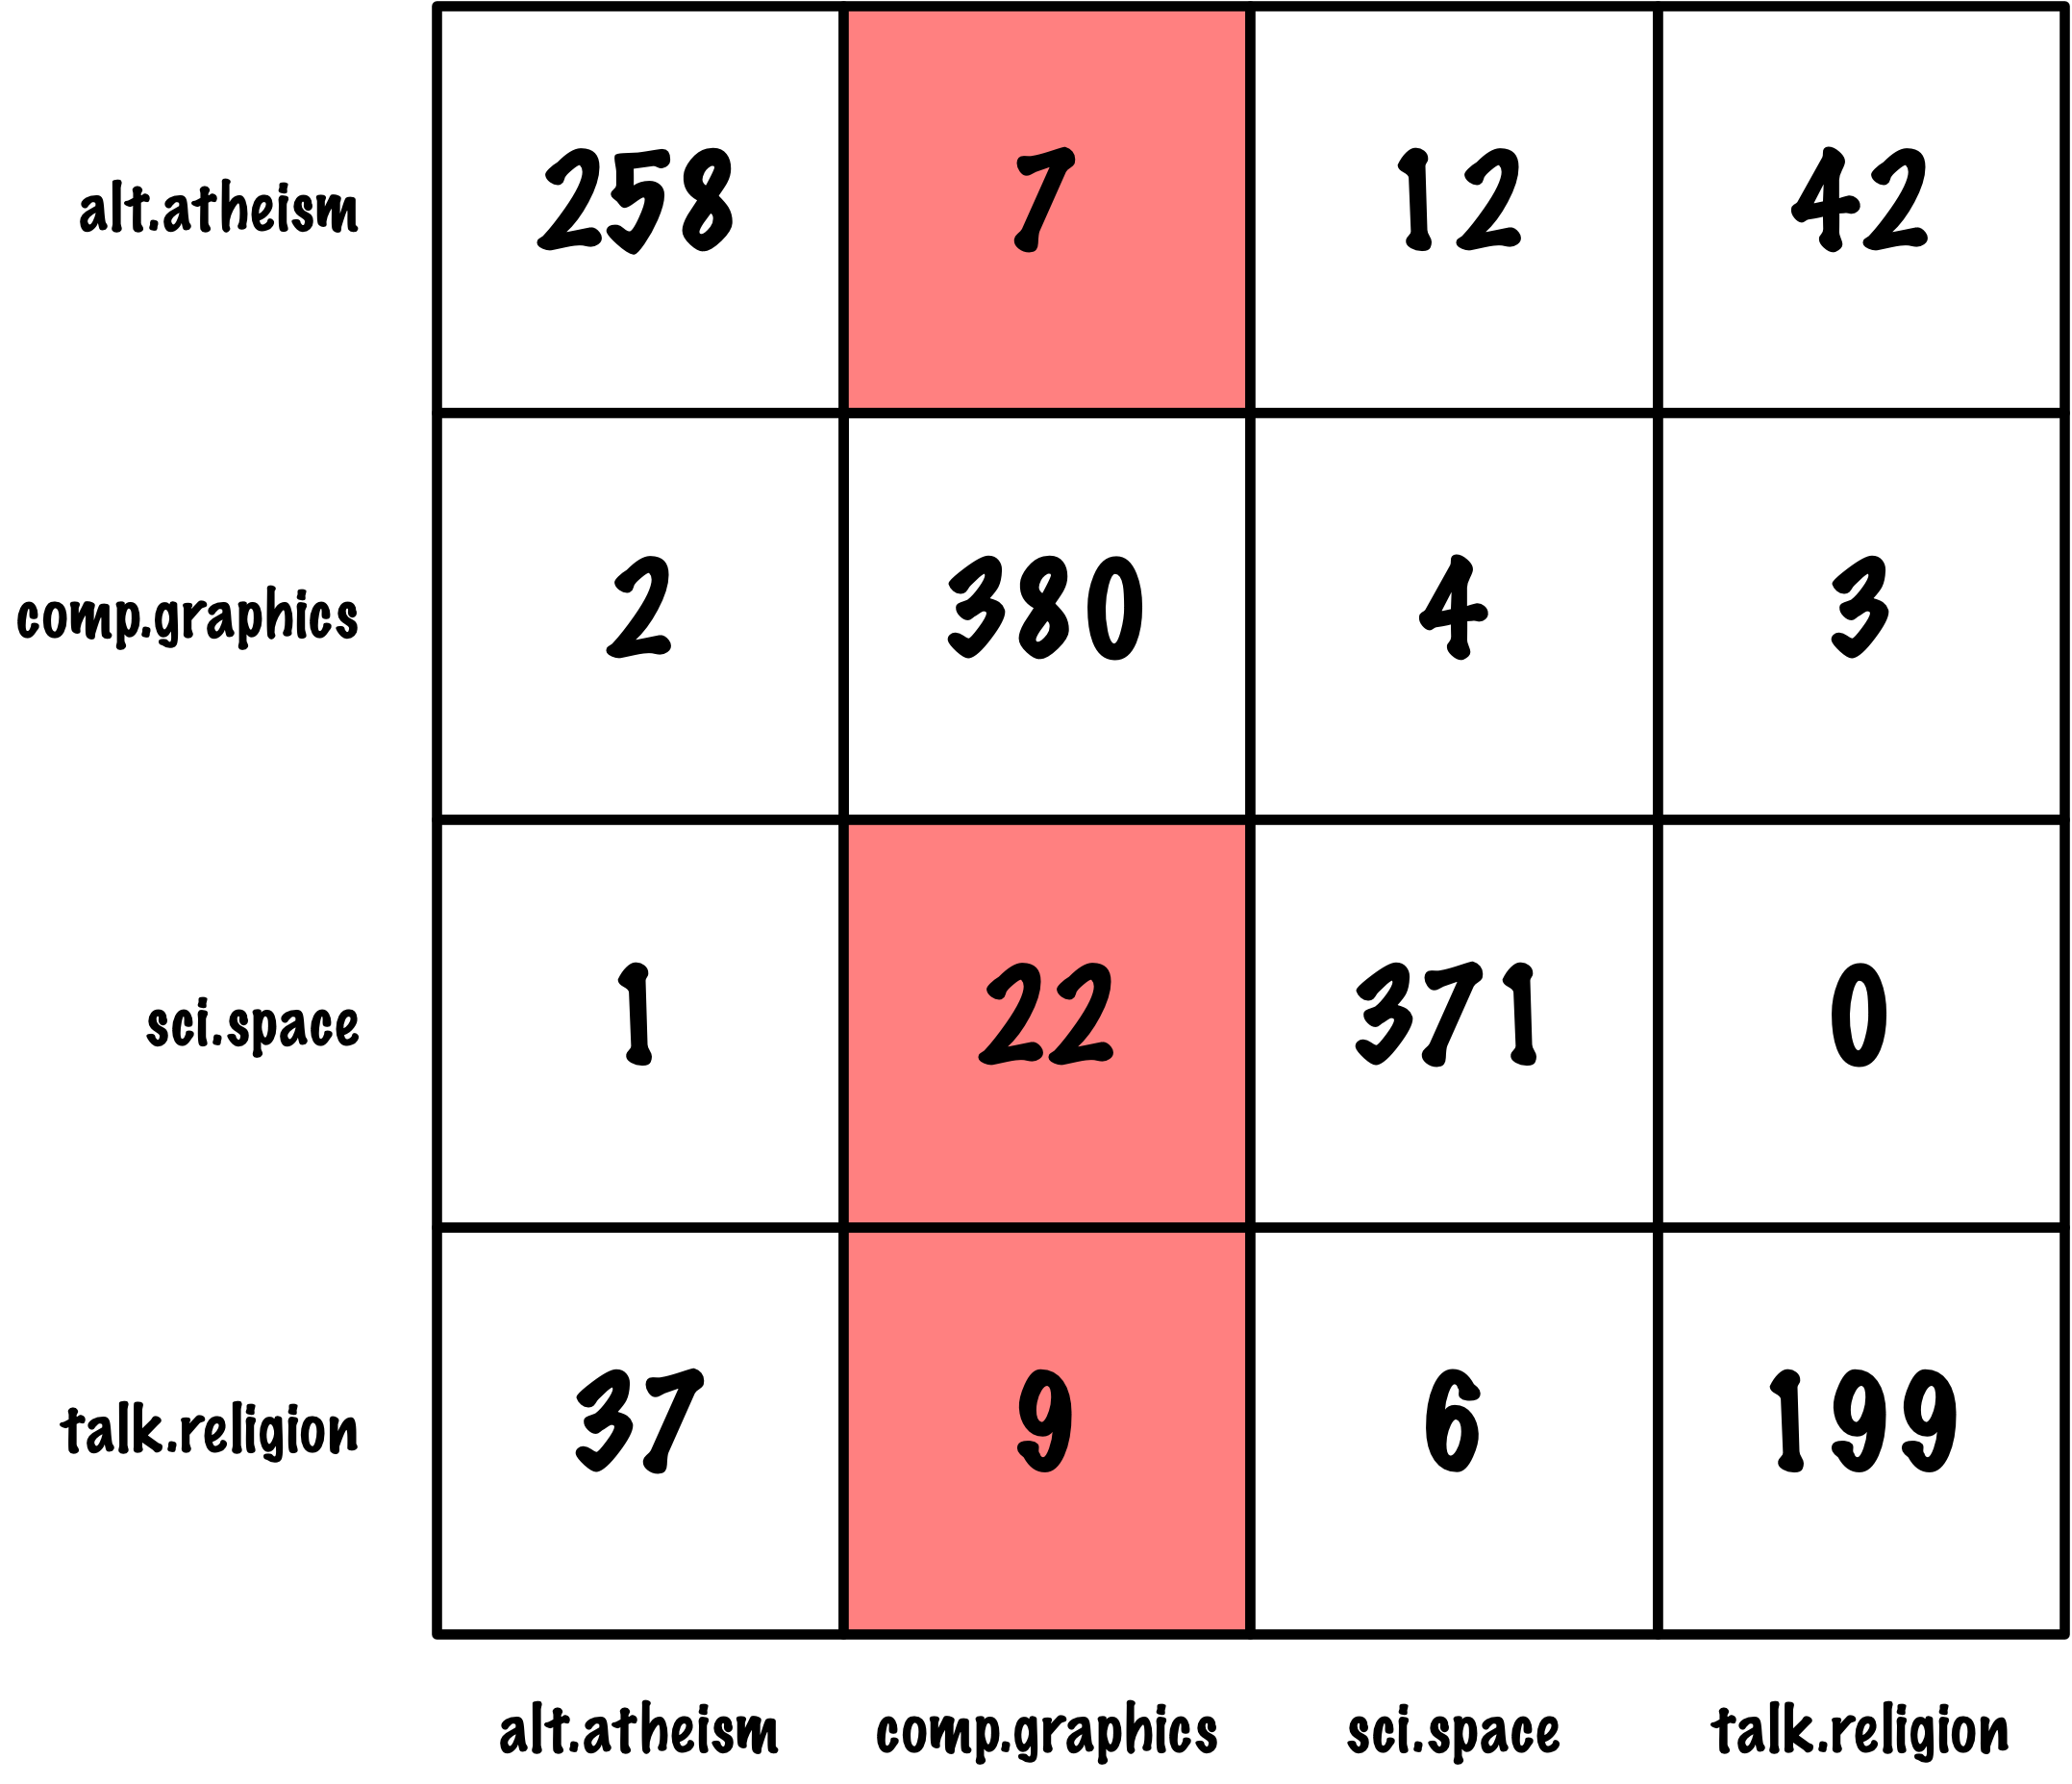

`comp.graphics` est la classe **vraie** ($i$).

## Matrice de confusion - faux négatif

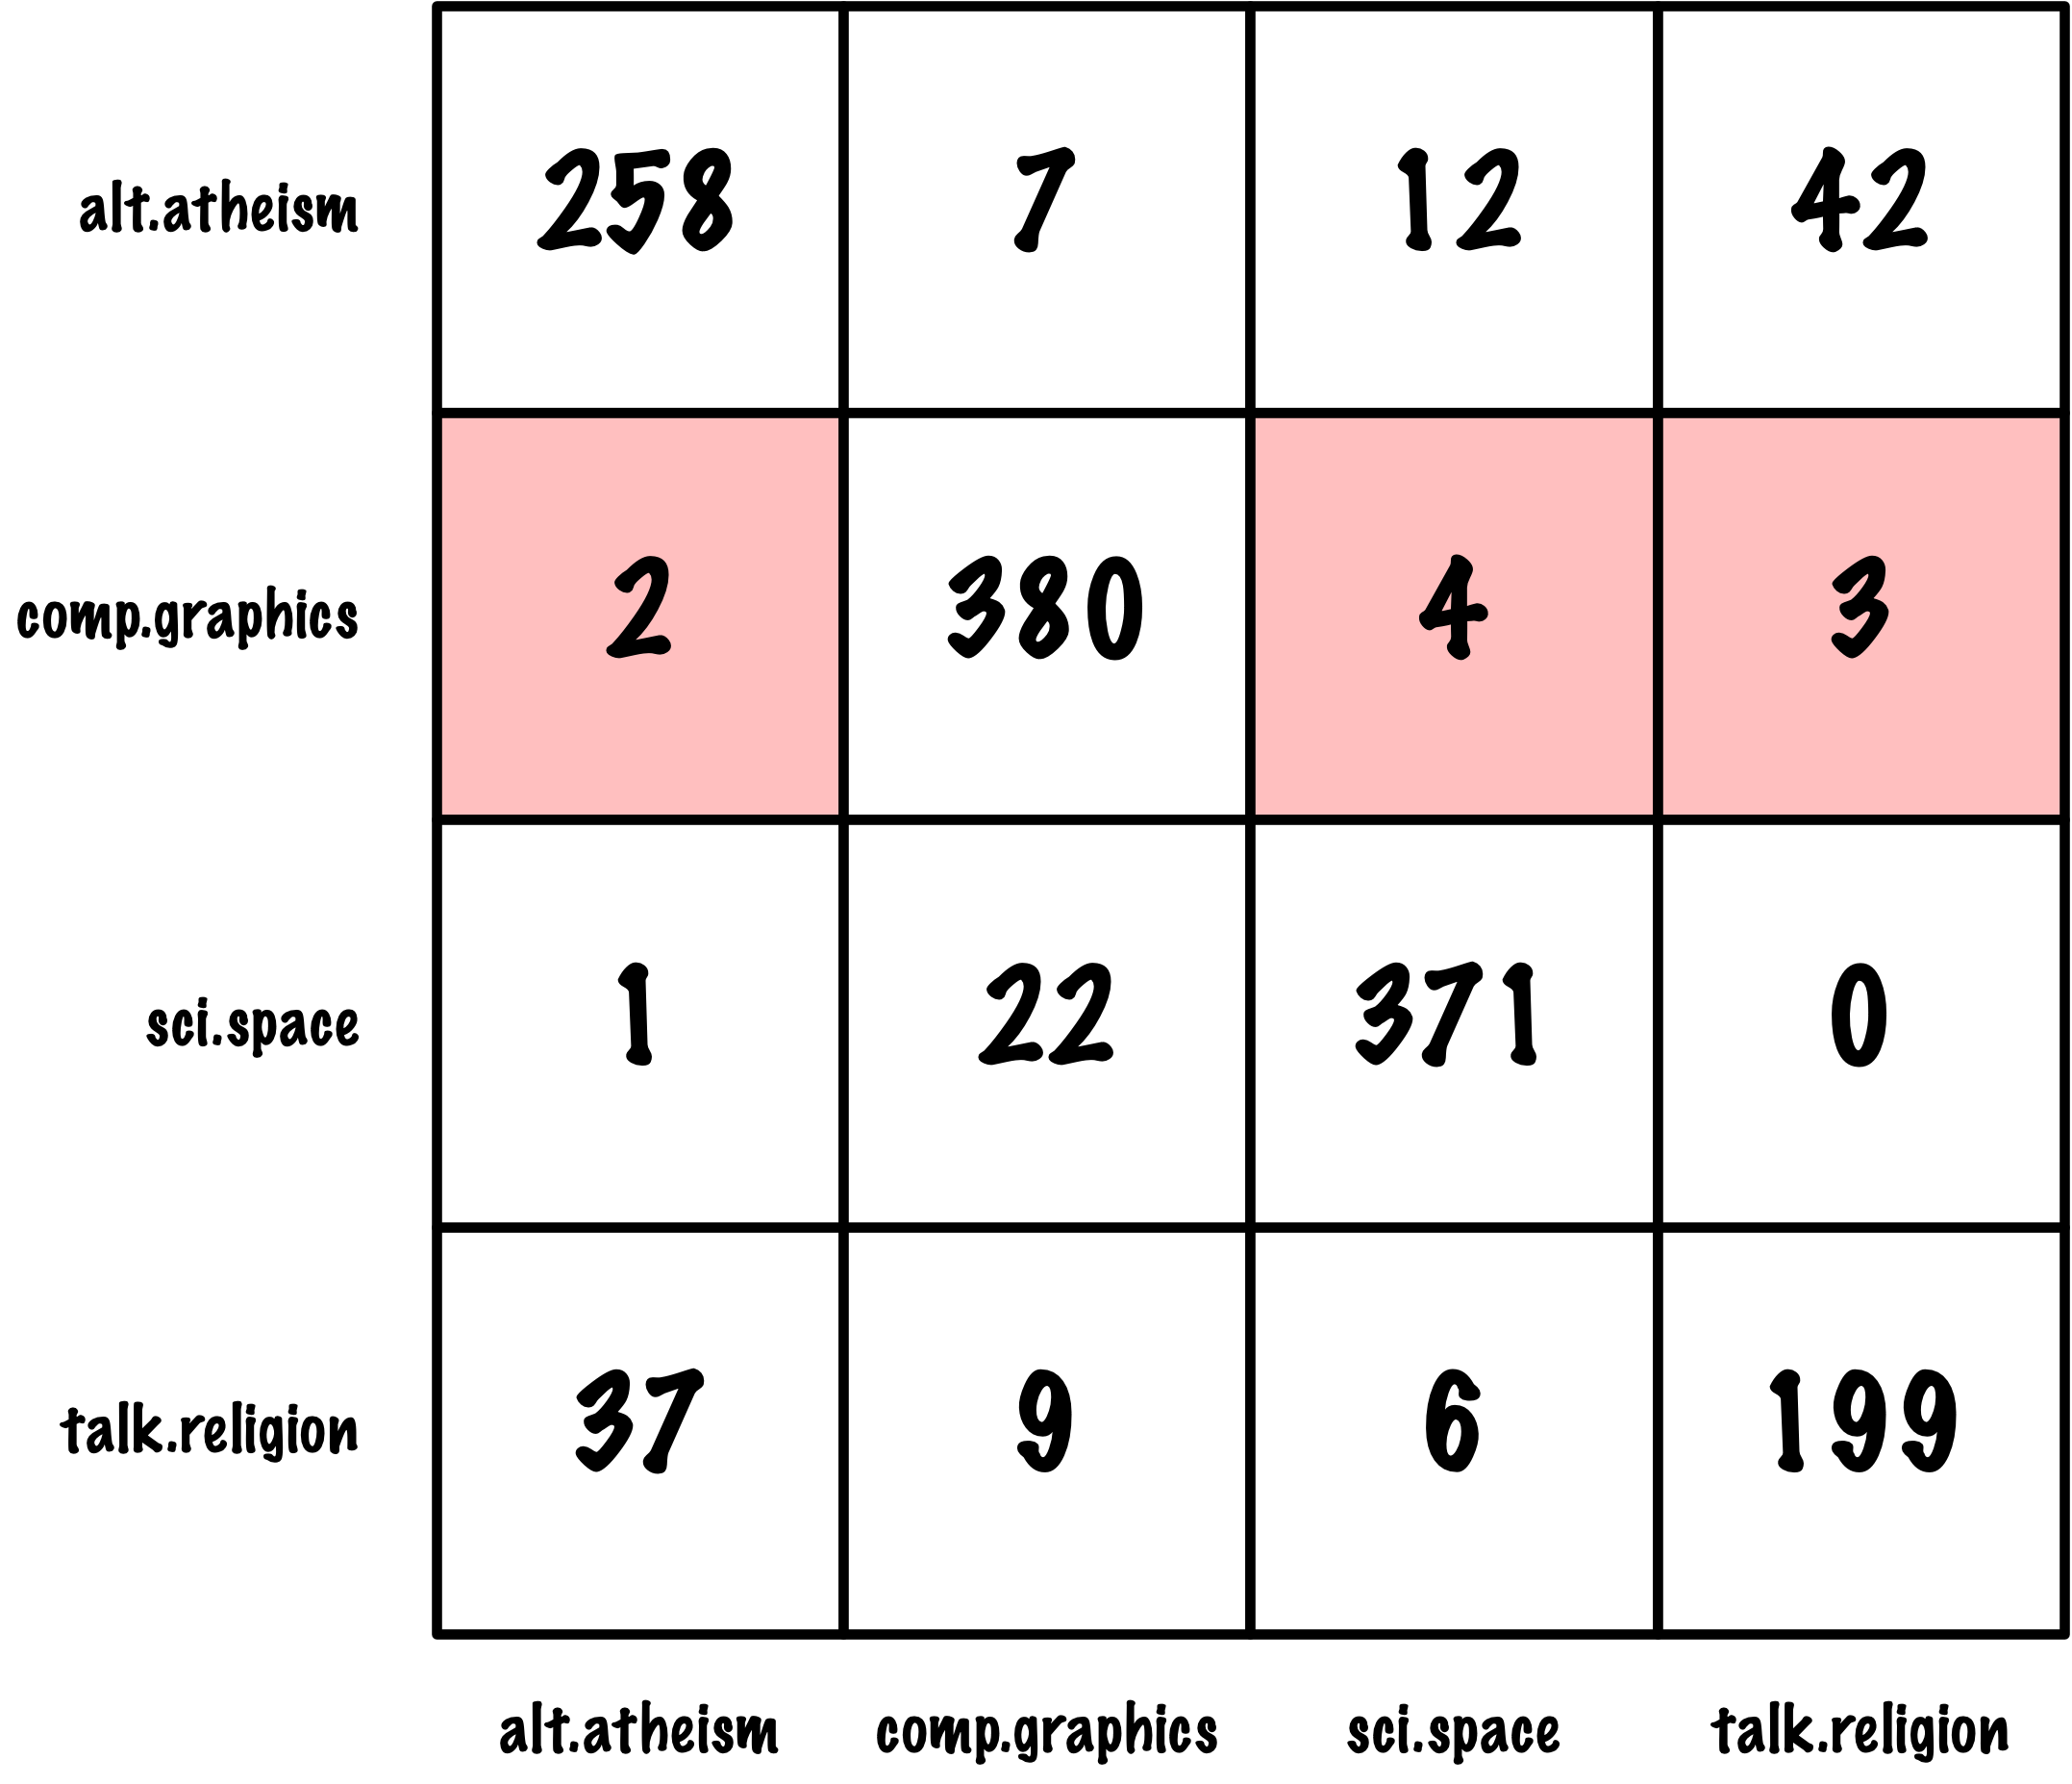

`comp.graphics` est la classe **vraie** ($i$).

## Matrice de confusion - vrai négatif

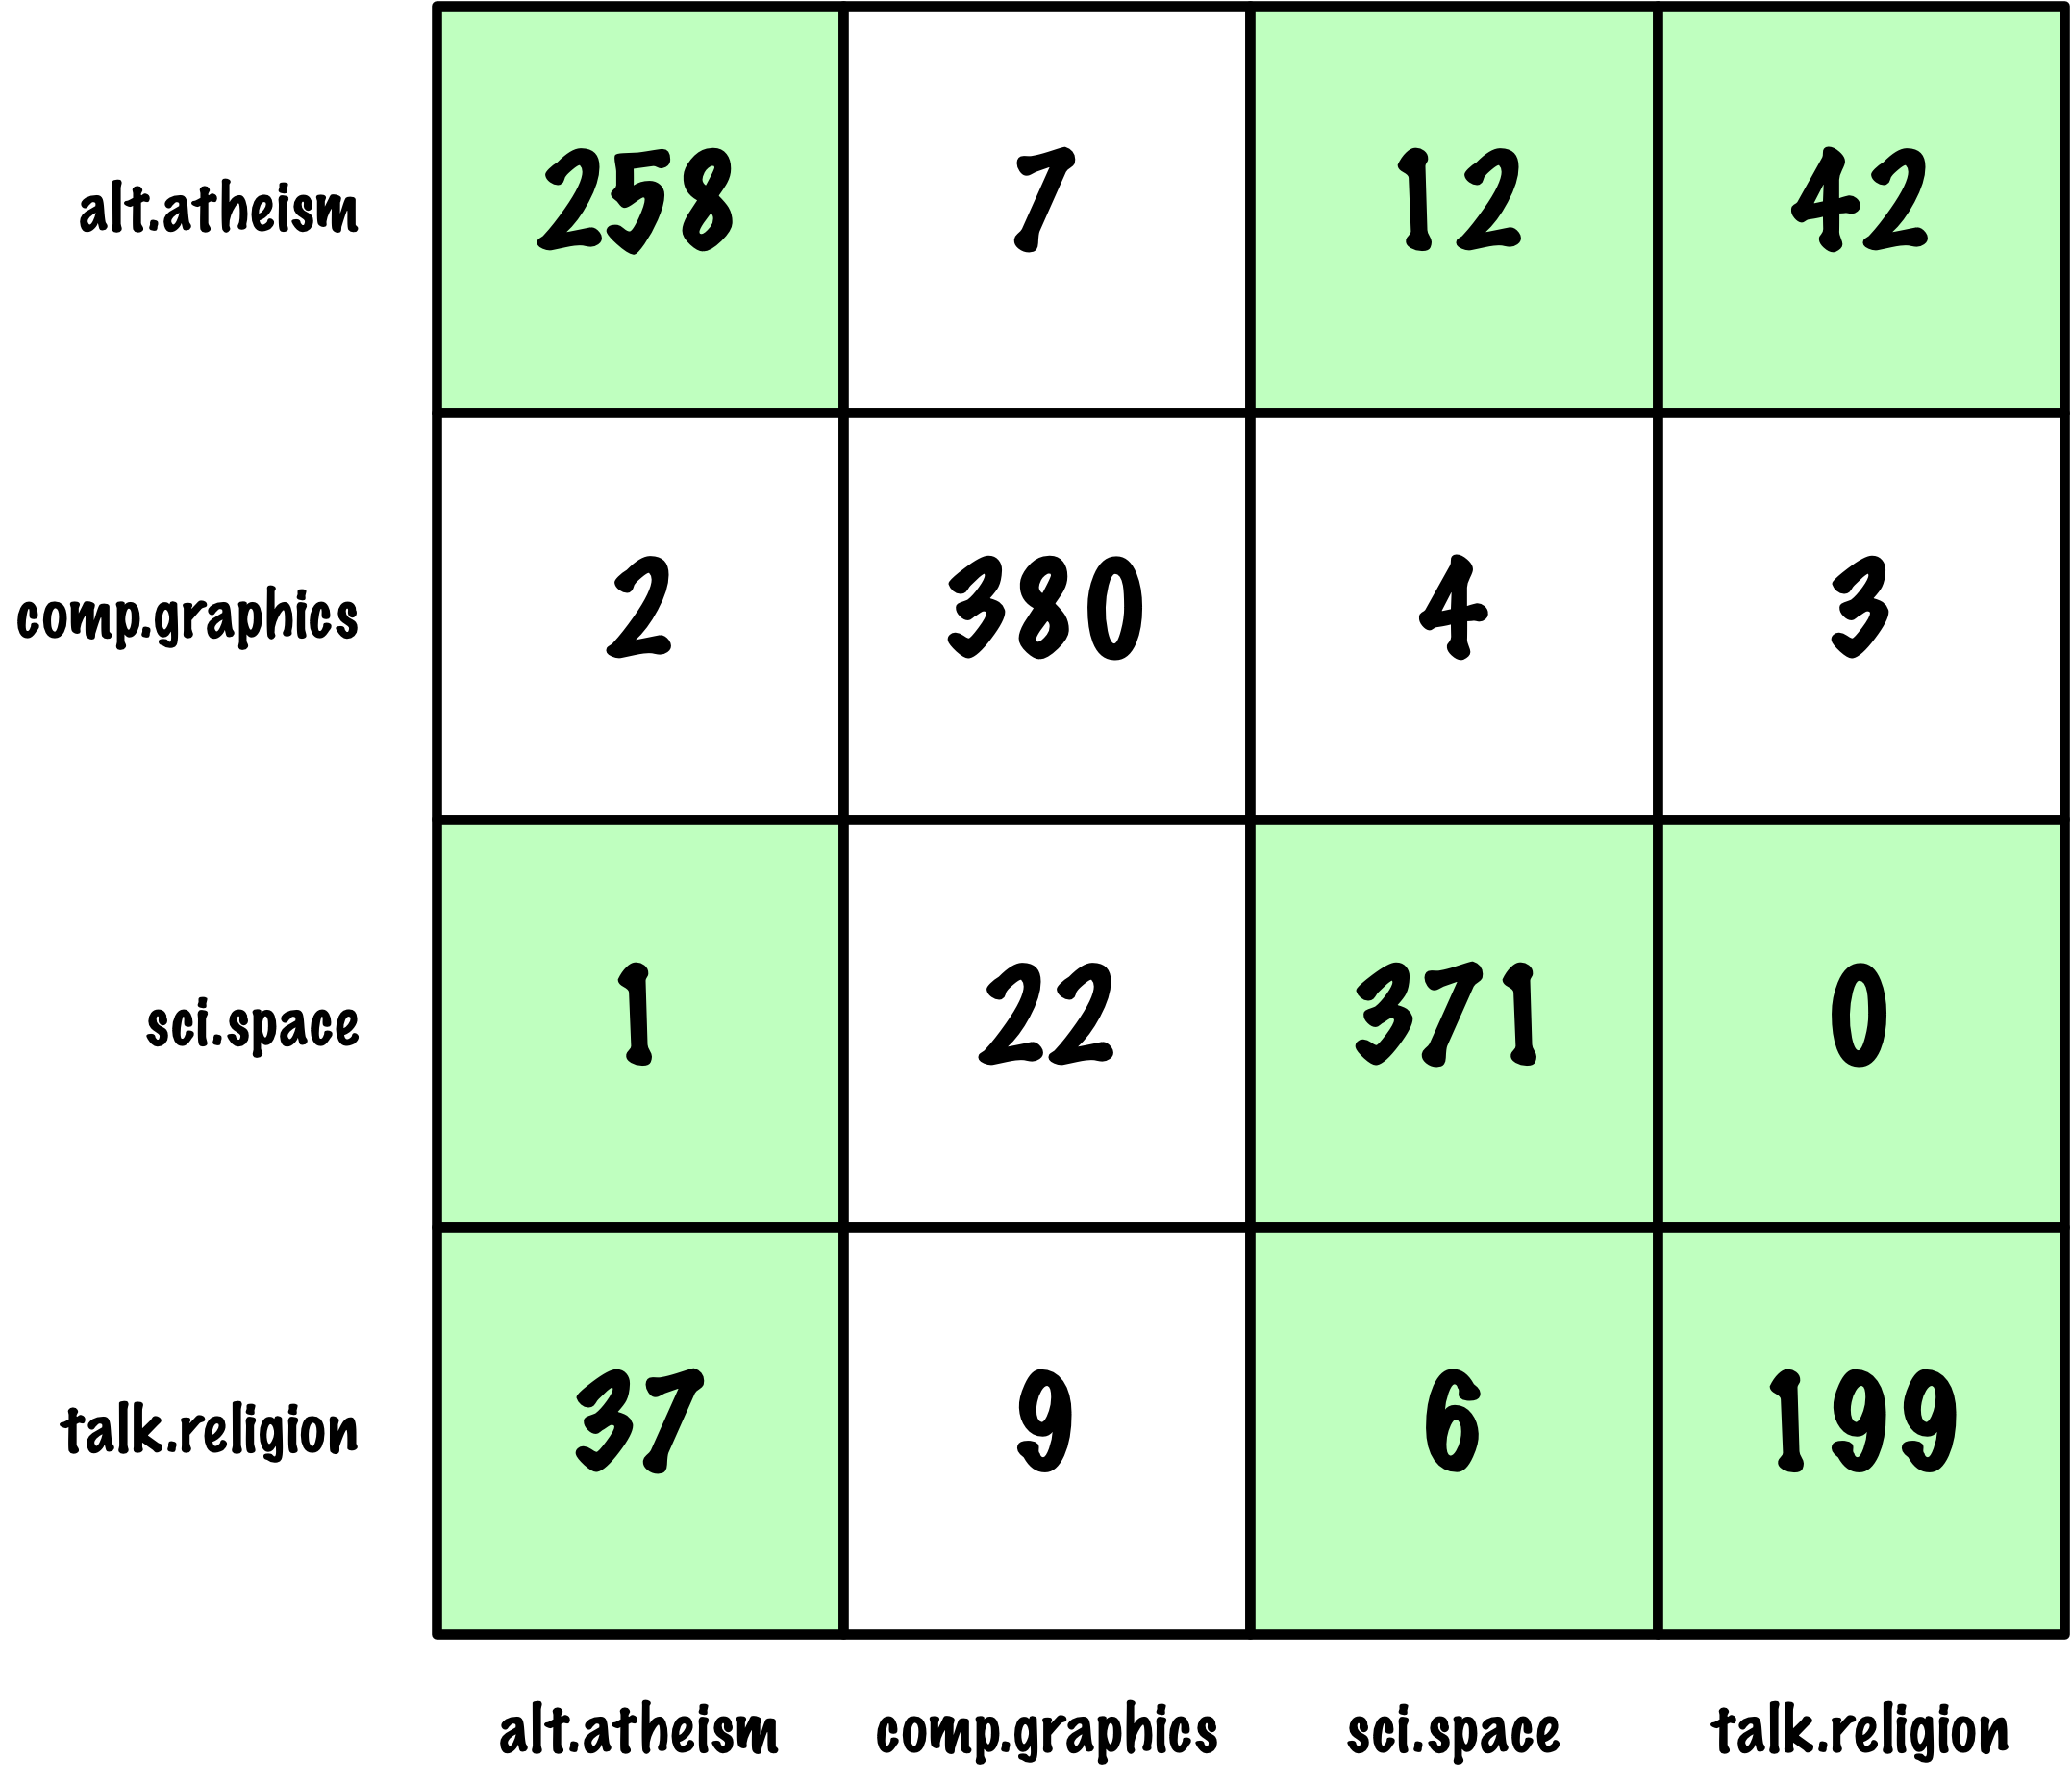

`comp.graphics` est la classe **vraie** ($i$).

## Matrice de confusion - multi-classes

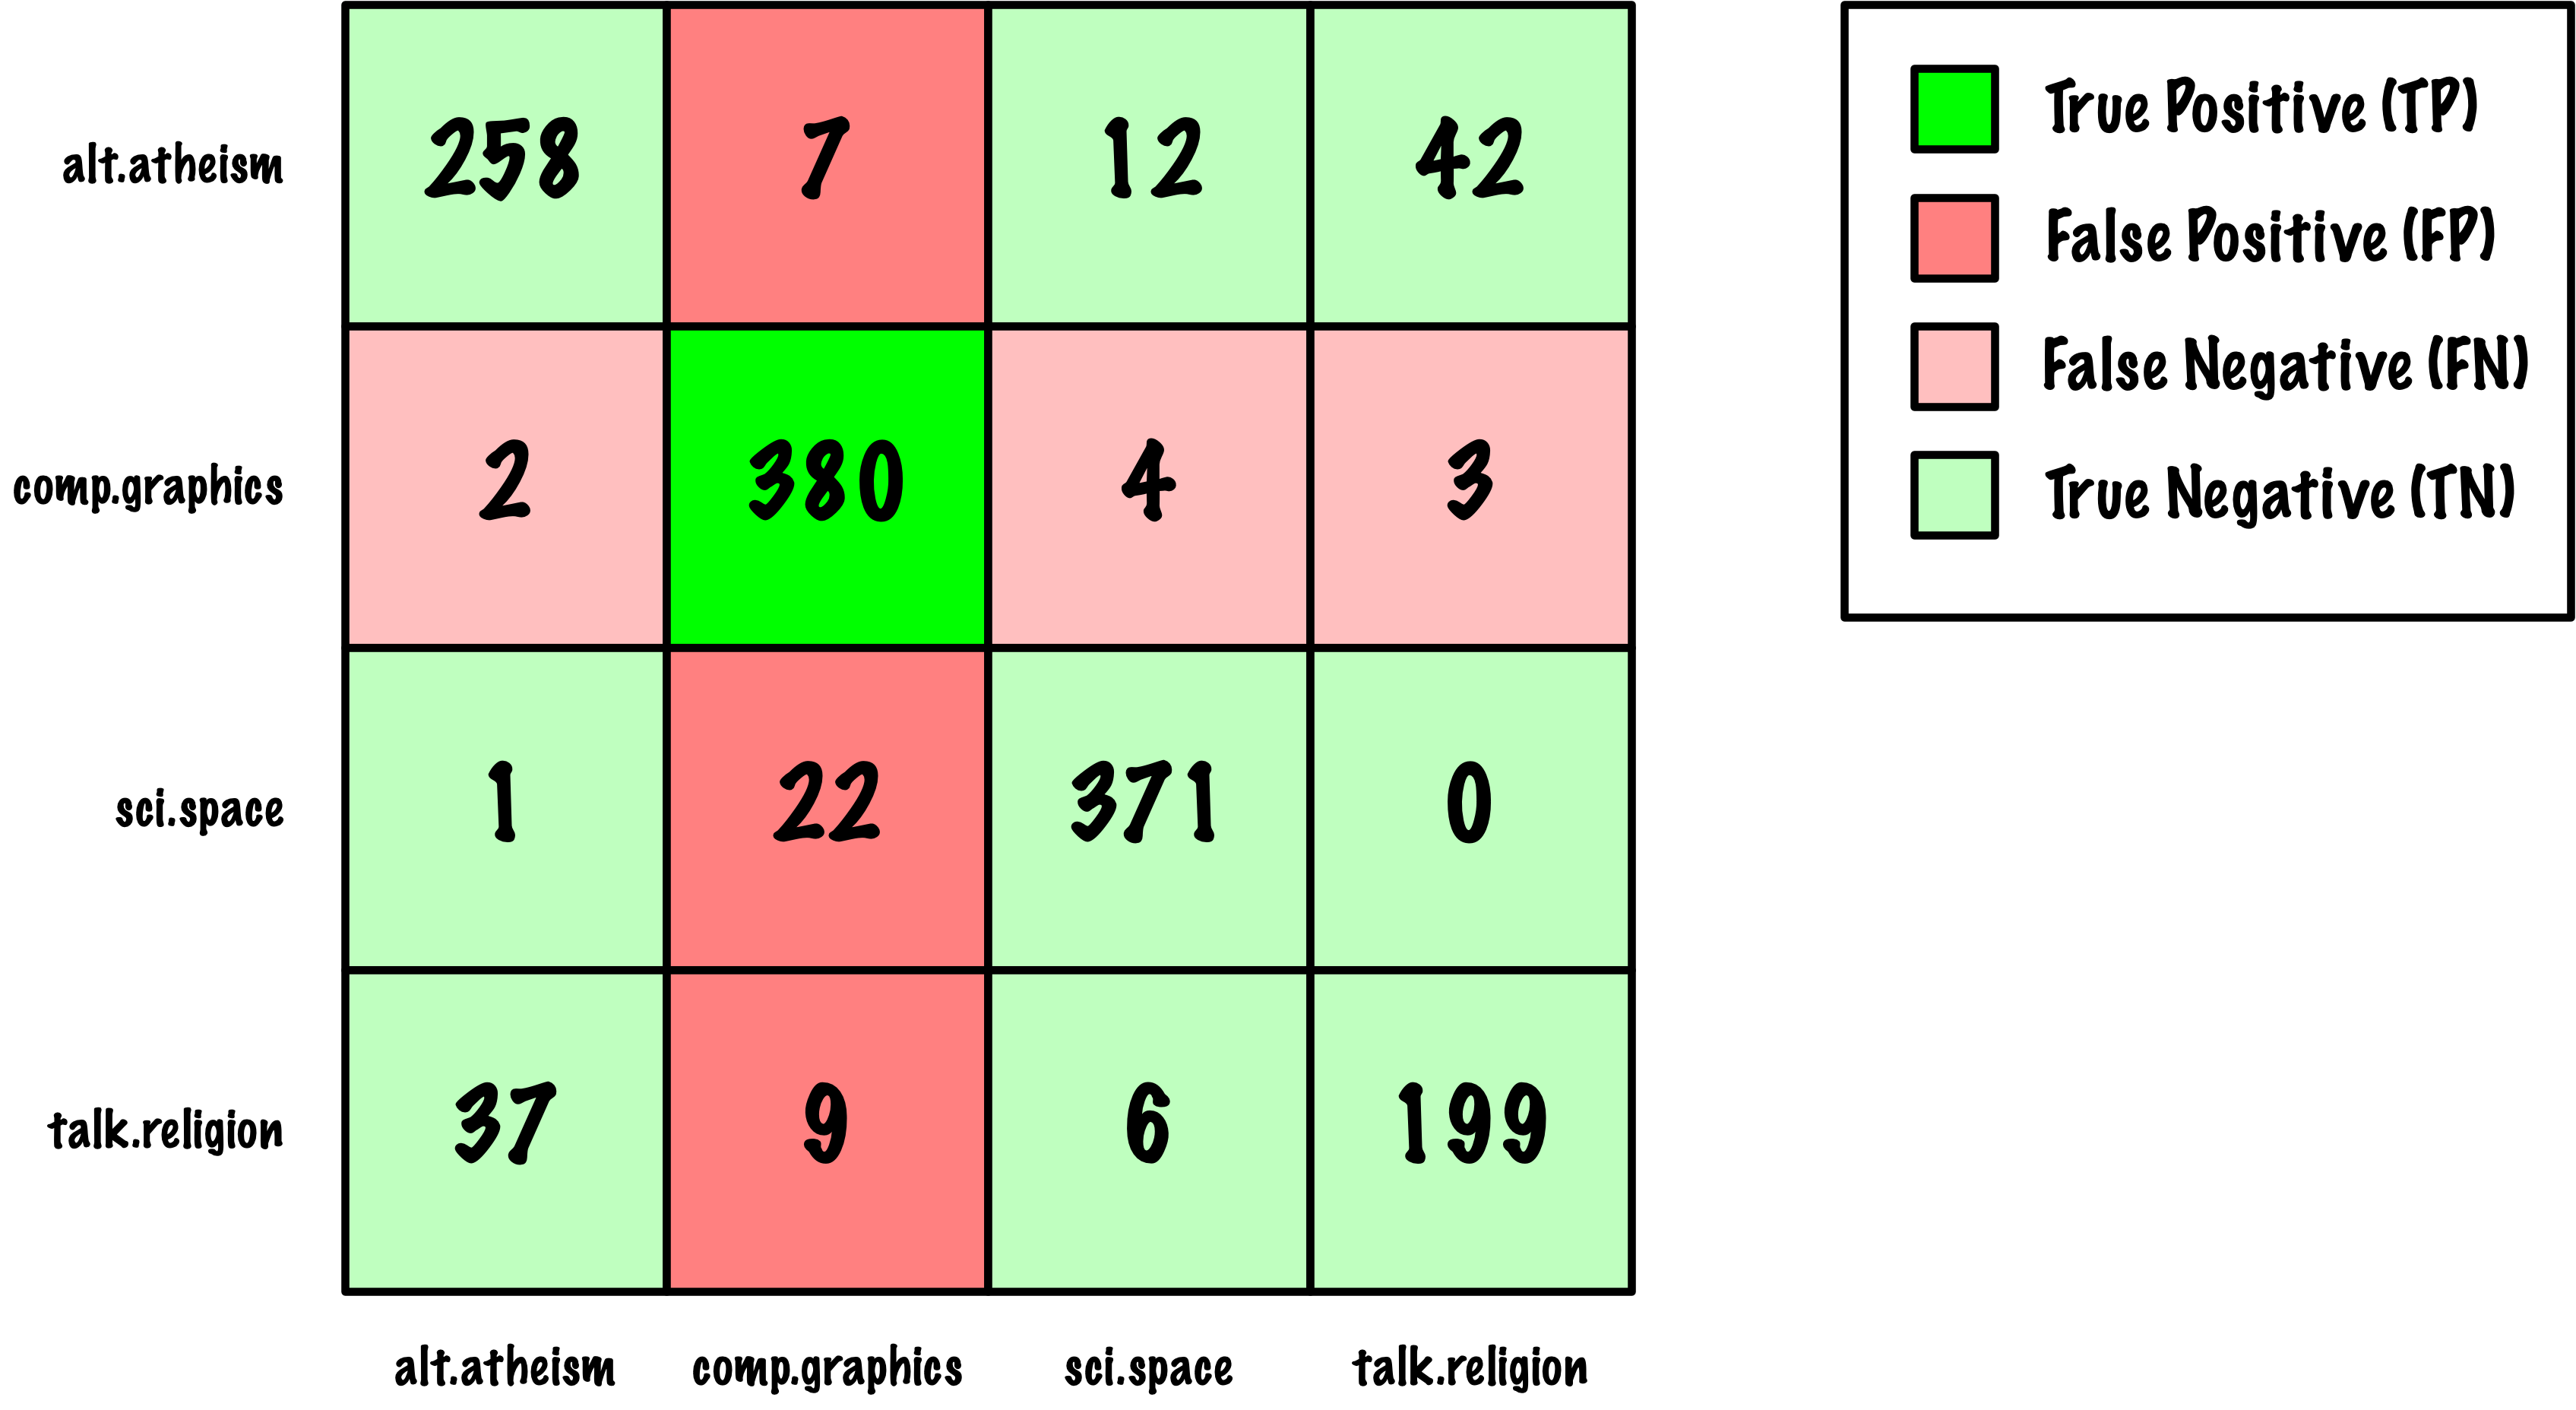

`comp.graphics` est la classe **vraie** ($i$).

## Multi-classes

Pour évaluer la performance dans un contexte multi-classes, on dérive
généralement des métriques “un-contre-tous” pour chaque classe à partir
de la matrice de confusion. Ces métriques sont ensuite moyennées en
utilisant des schémas de pondération spécifiques.

- **Vrais Positifs** ($\mathrm{TP}_i$) : Entrée diagonale $C_{i,i}$
- **Faux Positifs** ($\mathrm{FP}_i$) : Somme de la colonne $i$ excluant
  $C_{i,i}$
- **Faux Négatifs** ($\mathrm{FN}_i$) : Somme de la ligne $i$ excluant
  $C_{i,i}$
- **Vrais Négatifs** ($\mathrm{TN}_i$) :
  $N - (\mathrm{TP}_i + \mathrm{FP}_i + \mathrm{FN}_i)$

## Multi-classes

Pour évaluer la performance dans un contexte multi-classes, on dérive
généralement des métriques “un-contre-tous” pour chaque classe à partir
de la matrice de confusion. Ces métriques sont ensuite moyennées en
utilisant des schémas de pondération spécifiques.

- $\mathrm{TP}_i = C_{i,i}$
- $\mathrm{FP}_i = \sum_{k \ne i} C_{k,i}$
- $\mathrm{FN}_i = \sum_{k \ne i} C_{i,k}$
- $\mathrm{TN}_i = \sum_{j \ne i} \sum_{k \ne i} C_{j,k}$

## sklearn.metrics.confusion_matrix

In [3]:
from sklearn.metrics import confusion_matrix

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

confusion_matrix(y_actual,y_pred)

array([[1, 2],
       [3, 4]])

. . .

In [4]:
tn, fp, fn, tp = confusion_matrix(y_actual, y_pred).ravel().tolist()
(tn, fp, fn, tp)

(1, 2, 3, 4)

Par défaut, `sklearn.metrics.confusion_matrix` détermine l’ensemble des
étiquettes à partir des données
($\textrm{y_true} \cup \textrm{y_pred}$), et ensuite :

- Il les trie par ordre croissant (ce qui, pour les chaînes ou les types
  mixtes, correspond à l’ordre lexicographique de Python).
- Il construit ensuite la matrice de sorte que la ligne `i` corresponde
  à la classe réelle avec l’étiquette `labels[i]`, et la colonne `j`
  corresponde à la classe prédite avec l’étiquette `labels[j]`.

Donc, si vous ne passez pas `labels=...`, vous pouvez obtenir une
matrice de confusion avec un ordre de classes qui n’est pas celui que
vous attendez — surtout si vos classes sont des chaînes, ou si vous
supposez que l’ordre suit l’ordre d’apparition dans le jeu de données.

**Exemple**

``` python
from sklearn.metrics import confusion_matrix

y_true = ["dog", "cat", "cat", "dog"]
y_pred = ["dog", "dog", "cat", "cat"]

print(confusion_matrix(y_true, y_pred))
```

Résultat :

    [[1 1]
     [1 1]]

Ici, les lignes/colonnes sont dans l’ordre lexicographique :
`["cat", "dog"]`. Donc la matrice est :

- Ligne 0 : vrai = “chat”
- Ligne 1 : vrai = “chien”

**Contrôler l’ordre**

Pour imposer un ordre spécifique, vous devez passer l’argument labels :

``` python
confusion_matrix(y_true, y_pred, labels=["dog", "cat"])
```

Cela permutera l’ordre des lignes/colonnes en conséquence.

## Prédiction parfaite

In [5]:
y_actual = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]
y_pred   = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]

confusion_matrix(y_actual,y_pred)

array([[4, 0],
       [0, 6]])

. . .

In [6]:
tn, fp, fn, tp = confusion_matrix(y_actual, y_pred).ravel().tolist()  
(tn, fp, fn, tp)

(4, 0, 0, 6)

Lorsqu’un algorithme fait une classification parfaite, toutes les
valeurs non nulles (0) de la matrice de confusion apparaissent
exclusivement le long de sa diagonale.

Toutes les entrées hors diagonale, qui représentent des erreurs de
classification, seront nulles (0).

## Matrice de confusion : plusieurs classes

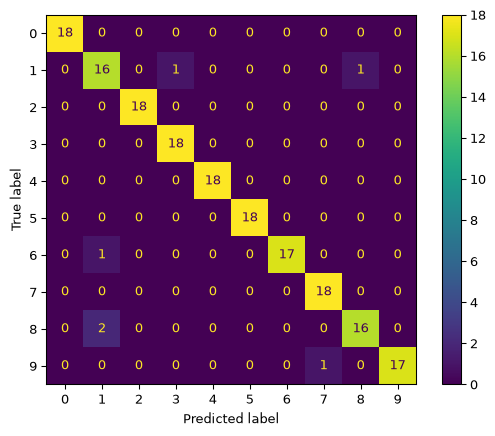

In [7]:
from sklearn.datasets import load_digits
import numpy as np

digits = load_digits()

X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=seed,
    stratify=y,
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from sklearn.multiclass import OneVsRestClassifier

clf = OneVsRestClassifier(LogisticRegression(max_iter=1000))
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

**Matrice de confusion** pour l’**exemple de chiffres manuscrits**
présenté lors du cours précédent.

L’image affiche une carte thermique de la matrice de confusion pour la
tâche de classification des chiffres. Cette tâche, un problème de
classification multiclasses, a été traitée en utilisant
`OneVsRestClassifier` et `LogisticRegression`.

La matrice de confusion résume les prédictions faites sur l’ensemble de
test, qui est un sous-ensemble des données qui n’a pas été utilisé pour
l’entraînement ni pour le prétraitement avec `StandardScaler`.

La matrice de confusion contient les résultats des prédictions sur
l’ensemble de test. Les métriques de performance résument ces
dénombrements en un plus petit nombre de valeurs.

## Visualisation des erreurs

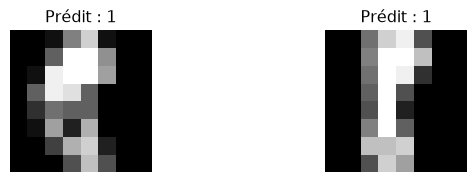

In [8]:
mask = (y_test == 8) & (y_pred == 1)
images_mal_classees = X_test[mask][:5]

plt.figure(figsize=(8, 2))
for index, image in enumerate(images_mal_classees):
    plt.subplot(1, len(images_mal_classees), index + 1)
    plt.imshow(np.reshape(image, (8,8)), cmap=plt.cm.gray)
    plt.title("Prédit : 1")
    plt.axis("off")

plt.tight_layout()
plt.show()

La matrice de confusion précédente montre des exemples dont l’étiquette
réelle est 8, mais dont la prédiction est 1. L’affichage des valeurs de
pixels originales, plutôt que des attributs standardisés fournis au
classificateur, préserve l’apparence de chaque chiffre.

## Exactitude

Quelle est l’**exactitude** de ce résultat ?

$$
  \mathrm{exactitude} = \frac{\mathrm{VP}+\mathrm{VN}}{\mathrm{VP}+\mathrm{VN}+\mathrm{FP}+\mathrm{FN}} = \frac{\mathrm{VP}+\mathrm{VN}}{\mathrm{N}}
$$

In [9]:
from sklearn.metrics import accuracy_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

accuracy_score(y_actual,y_pred)

0.5

L’**exactitude** est le rapport entre les instances correctement
prédites et le nombre total de prédictions.

Dans le contexte francophone, le terme « accuracy » se traduit
généralement par « exactitude ». Il est important de noter que certaines
applications utilisent à tort le terme « précision » pour désigner
« accuracy ». Or, « précision » correspond en réalité au terme anglais
« precision », qui possède une signification distincte.

## Exactitude

In [10]:
y_actual = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]
y_pred   = [1, 0, 1, 1, 0, 0, 0, 1, 0, 0]

accuracy_score(y_actual,y_pred)

0.0

In [11]:
y_actual = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]
y_pred   = [0, 1, 0, 0, 1, 1, 1, 0, 1, 1]

accuracy_score(y_actual,y_pred)

1.0

L’**exactitude** est un nombre entre 0 (tout faux) et 1 (parfait).

## L’exactitude peut être trompeuse

In [12]:
y_actual = [0, 0, 0, 0, 1, 1, 0, 0, 0, 0]
y_pred   = [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

accuracy_score(y_actual,y_pred)

0.8

**Pourquoi** est-ce problématique ?

Le **déséquilibre des classes** survient lorsqu’une classe contient
beaucoup plus d’exemples qu’une autre. L’exactitude peut alors refléter
de manière disproportionnée la performance sur la classe majoritaire et
masquer une mauvaise performance sur la classe minoritaire.

À mesure que le déséquilibre augmente, l’exactitude peut devenir de plus
en plus trompeuse. Nous reviendrons sur cette question plus loin lorsque
nous introduirons les moyennes micro et macro.

## Précision

Aussi connu sous le nom de **valeur prédictive positive** (PPV).

$$
  \mathrm{précision} = \frac{\mathrm{VP}}{\mathrm{VP}+\mathrm{FP}}
$$

In [13]:
from sklearn.metrics import precision_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

precision_score(y_actual, y_pred)

0.6666666666666666

La **précision** est la proportion de **prédictions positives vraies**
parmi **toutes les prédictions positives**.

Pouvez-vous penser à un problème ou à une situation où la précision est
particulièrement importante ?

Un exemple est la sélection de composés candidats en vue d’une
validation coûteuse en laboratoire.

- Un modèle examine une grande bibliothèque de composés et prédit
  lesquels sont actifs.
- Chaque prédiction positive déclenche une expérience coûteuse.
- Une précision élevée signifie qu’une plus grande proportion des
  composés testés sont réellement actifs :

$$
\text{Précision} = \frac{\text{VP}}{\text{VP} + \text{FP}}
$$

- Une précision plus élevée réduit le nombre d’expériences consacrées à
  des composés inactifs.

Autres contextes réels où la précision est essentielle :

- Détection du pourriel : une précision élevée évite de masquer des
  messages légitimes.
- Recherche de documents juridiques : une précision élevée réduit le
  temps consacré à des résultats non pertinents.
- Systèmes de recommandation : une précision élevée rend les
  recommandations plus susceptibles d’intéresser les utilisateurs.

## La précision seule ne suffit pas

In [14]:
y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]

precision_score(y_actual,y_pred)

1.0

Un algorithme qui fait un petit nombre de prédictions à haute confiance
pourrait atteindre un score de précision élevé, mais cela ne sera pas
nécessairement utile.

## Rappel

Aussi connu sous le nom de **sensibilité** ou **taux de vrais positifs**
(TPR)

$$
  \mathrm{rappel} = \frac{\mathrm{VP}}{\mathrm{VP}+\mathrm{FN}}
$$

In [15]:
from sklearn.metrics import recall_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

recall_score(y_actual,y_pred)

0.5714285714285714

**Rappel** est la proportion d’instances positives correctes identifiées
parmi toutes les instances réellement positives.

Pouvez-vous penser à un problème ou une situation où le rappel est
primordial ?

Un exemple où le rappel est la mesure critique : **diagnostic du cancer
(dépistage des tumeurs malignes)**.

- Ici, les faux négatifs (manquer un cas réel de cancer) sont beaucoup
  plus dangereux que les faux positifs.
- Le rappel mesure la proportion de vrais positifs correctement
  identifiés :

$$
\text{Rappel} = \frac{\text{VP}}{\text{VP} + \text{FN}}
$$

- Un rappel élevé signifie que le test détecte presque tous les patients
  atteints de cancer, même s’il génère également quelques fausses
  alertes.
- Manquer un cas réel (rappel faible) pourrait signifier qu’un patient
  ne reçoit pas de traitement à temps — une erreur beaucoup plus grave
  que d’investiguer quelques faux positifs supplémentaires.

Autres contextes réels où le rappel est le plus important :

- Sécurité / Détection d’intrusions : Mieux vaut signaler toute activité
  suspecte (même avec des faux positifs) que de manquer une véritable
  attaque.
- Moteurs de recherche : Pour certaines requêtes (par exemple, recherche
  de précédents juridiques, recherche de littérature médicale), le
  rappel garantit que vous récupérez tous les documents pertinents.
- Systèmes de réponse d’urgence : Pour les alertes de catastrophes
  naturelles, un rappel élevé garantit qu’aucune menace réelle ne passe
  inaperçue.

## Score F$_1$

$$
\begin{align*}
  F_1~\mathrm{score} &= \frac{2}{\frac{1}{\mathrm{précision}}+\frac{1}{\mathrm{rappel}}} = 2 \times \frac{\mathrm{précision}\times\mathrm{rappel}}{\mathrm{précision}+\mathrm{rappel}} \\
                     &= \frac{\mathrm{VP}}{\mathrm{VP}+\frac{\mathrm{FN}+\mathrm{FP}}{2}}
\end{align*}
$$

In [16]:
from sklearn.metrics import f1_score

y_actual = [0, 0, 0, 1, 1, 1, 1, 1, 1, 1]
y_pred   = [0, 1, 1, 0, 0, 0, 1, 1, 1, 1]

f1_score(y_actual,y_pred)

0.6153846153846154

**F$_1$** est la **moyenne harmonique** de la précision et du rappel.

- La moyenne harmonique est attirée vers la plus faible des deux
  valeurs. Un score $F_1$ élevé exige donc une précision et un rappel
  élevés.
- Le score $F_1$ accorde la même importance à la précision et au rappel.
  Une application où les coûts des erreurs sont inégaux peut nécessiter
  une autre métrique ou un choix explicite du seuil.
- L’augmentation du **rappel** réduit souvent la **précision**, et
  inversement. Cette relation constitue le **compromis
  précision-rappel**.

# Moyennes micro et macro

## Définition

Le **problème de déséquilibre des classes** survient lorsqu’une classe
contient beaucoup plus d’exemples qu’une autre.

. . .

Sans choix appropriés pour l’entraînement et l’évaluation, un modèle
peut favoriser la **classe majoritaire** et obtenir de mauvais résultats
sur la **classe minoritaire**.

Les métriques d’évaluation courantes, comme l’exactitude, peuvent être
trompeuses en présence d’un déséquilibre des classes.

Les deux diapositives suivantes présentent les moyennes micro et macro.
La distinction peut sembler abstraite au départ. Les exemples concrets
fondés sur des matrices de confusion montreront précisément quels
dénombrements chaque méthode combine et pourquoi les deux moyennes
peuvent différer.

## Mesures de performance micro

- La moyenne micro **regroupe les vrais positifs, les faux positifs et
  les faux négatifs de toutes les classes** avant de calculer la
  précision, le rappel ou le score $F_1$.
- Elle **traite chaque prédiction de la même manière**. Les classes
  fréquentes contribuent donc davantage à la métrique finale.

## Mesures de performance macro

- La moyenne macro **calcule la métrique séparément pour chaque classe,
  puis prend la moyenne arithmétique**.
- Elle **traite chaque classe de la même manière**, quelle que soit sa
  fréquence. Une mauvaise performance sur une classe peu fréquente
  demeure donc visible.

Un moyen mnémotechnique utile repose sur le niveau d’agrégation :

- **Micro** travaille au niveau plus fin des prédictions individuelles.
  Elle regroupe les contributions de chaque exemple avant de calculer la
  métrique.
- **Macro** travaille au niveau des classes. Elle calcule une métrique
  pour chaque classe, chacune regroupant plusieurs exemples, puis fait
  la moyenne de ces valeurs.

## Multi-classe

Lors du calcul de la **précision**, du **rappel** et de $F_1$, on
calcule généralement les métriques “un-contre-tous” pour chaque classe.
Ensuite, on les moyenne en utilisant des schémas de pondération (macro,
micro).

- **Vrais Positifs** ($\mathrm{TP}_i$) : Entrée diagonale $C_{i,i}$
- **Faux Positifs** ($\mathrm{FP}_i$) : Somme de la colonne $i$ à
  l’exception de $C_{i,i}$
- **Faux Négatifs** ($\mathrm{FN}_i$) : Somme de la ligne $i$ à
  l’exception de $C_{i,i}$
- **Vrais Négatifs** ($\mathrm{TN}_i$) :
  $N - (\mathrm{TP}_i + \mathrm{FP}_i + \mathrm{FN}_i)$

## Multi-classe

Lors du calcul de la **précision**, du **rappel** et de $F_1$, on
calcule généralement les métriques “un-contre-tous” pour chaque classe.
Ensuite, on les moyenne en utilisant des schémas de pondération (macro,
micro).

- $\mathrm{TP}_i = C_{i,i}$
- $\mathrm{FP}_i = \sum_{k \ne i} C_{k,i}$
- $\mathrm{FN}_i = \sum_{k \ne i} C_{i,k}$
- $\mathrm{TN}_i = \sum_{j \ne i} \sum_{k \ne i} C_{j,k}$

## Micro/Macro

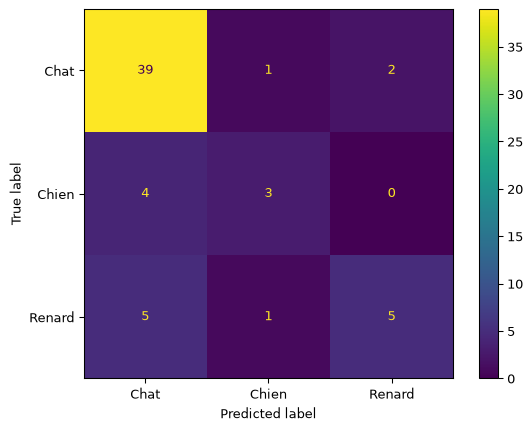

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

# Données d'exemple
y_true = ['Chat'] * 42 + ['Chien'] *  7 + ['Renard'] * 11
y_pred = ['Chat'] * 39 + ['Chien'] *  1 + ['Renard'] *  2 + \
         ['Chat'] *  4 + ['Chien'] *  3 + ['Renard'] *  0 + \
         ['Chat'] *  5 + ['Chien'] *  1 + ['Renard'] *  5

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

Le jeu de données peut être conceptualisé comme résultant d’une **tâche
de classification d’images**, impliquant des images de **chats**,
**chiens** et **renards**. Reflétant les tendances courantes observées
sur internet, les images de chats sont disproportionnellement
représentées, entraînant un problème de **déséquilibre des classes**.

## Précision micro/macro

In [18]:
from sklearn.metrics import classification_report, precision_score

print(classification_report(y_true, y_pred), "\n")

precision_micro = precision_score(y_true, y_pred, average="micro")
precision_macro = precision_score(y_true, y_pred, average="macro")
print(f"Précision micro : {precision_micro:.2f}")
print(f"Précision macro : {precision_macro:.2f}")

              precision    recall  f1-score   support

        Chat       0.81      0.93      0.87        42
       Chien       0.60      0.43      0.50         7
      Renard       0.71      0.45      0.56        11

    accuracy                           0.78        60
   macro avg       0.71      0.60      0.64        60
weighted avg       0.77      0.78      0.77        60
 

Précision micro : 0.78
Précision macro : 0.71

## Précision micro/macro

- La **précision moyenne macro** est calculée comme la moyenne des
  scores de **précision**[1] pour chaque classe :
  $\frac{0.81 + 0.60 + 0.71}{3} = 0.71$.

- Tandis que, la **précision moyenne micro** est calculée en utilisant
  la formule, $\frac{TP}{TP+FP}$ et les **données de toute la matrice de
  confusion** $\frac{39+3+5}{39+3+5+9+2+2} = \frac{47}{60} = 0.78$

La précision micro élevée observée ici provient surtout de la bonne
performance et du grand nombre d’exemples de la classe majoritaire,
Chat. Elle masque la performance relativement faible sur les classes
minoritaires, Chien et Renard.

Les moyennes micro et macro sont semblables lorsque les fréquences des
classes et les performances propres à chaque classe sont semblables.
L’équilibre des classes ne garantit pas à lui seul que les deux moyennes
seront égales.

Avec des classes déséquilibrées, une mauvaise performance sur une classe
minoritaire peut avoir peu d’effet sur la moyenne micro, mais un effet
important sur la moyenne macro.

Dans les **métriques macro**, chaque classe contribue également à la
valeur finale, **indépendamment du nombre d’exemples qu’elle contient**.
La métrique est calculée séparément pour chaque classe, puis ces valeurs
sont moyennées sans pondération par la fréquence.

## Rappel micro/macro

[1] Par conséquent, la précision moyenne macro reste inchangée par le
nombre variable d’exemples dans les différentes classes.

In [19]:
from sklearn.metrics import classification_report, recall_score

print(classification_report(y_true, y_pred), "\n")

micro_recall = recall_score(y_true, y_pred, average="micro")
macro_recall = recall_score(y_true, y_pred, average="macro")
print(f"Rappel micro : {micro_recall:.2f}")
print(f"Rappel macro : {macro_recall:.2f}")

              precision    recall  f1-score   support

        Chat       0.81      0.93      0.87        42
       Chien       0.60      0.43      0.50         7
      Renard       0.71      0.45      0.56        11

    accuracy                           0.78        60
   macro avg       0.71      0.60      0.64        60
weighted avg       0.77      0.78      0.77        60
 

Rappel micro : 0.78
Rappel macro : 0.60

## Rappel micro/macro

- Le **rappel moyen macro** est calculé comme la **moyenne des scores de
  rappel pour chaque classe** : $\frac{0.93 + 0.43 + 0.45}{3} = 0.60$.

- Le **rappel moyen micro** regroupe les décomptes de toute la matrice
  de confusion :
  $\frac{TP}{TP+FN} = \frac{39+3+5}{39+3+5+3+4+6} = \frac{47}{60} = 0.78$.

Dans une classification multiclasse à étiquette unique, chaque exemple
contribue une étiquette réelle et une étiquette prédite. Par conséquent,

$$
\text{précision micro}
= \text{rappel micro}
= F_1\text{ micro}
= \text{exactitude}.
$$

Dans cet exemple, toutes les métriques micro valent $47/60 = 0.78$. Les
moyennes macro peuvent différer, car elles accordent le même poids à
chaque classe.

# Déséquilibre des classes dans les données médicales

## Mesures micro/macro (données médicales)

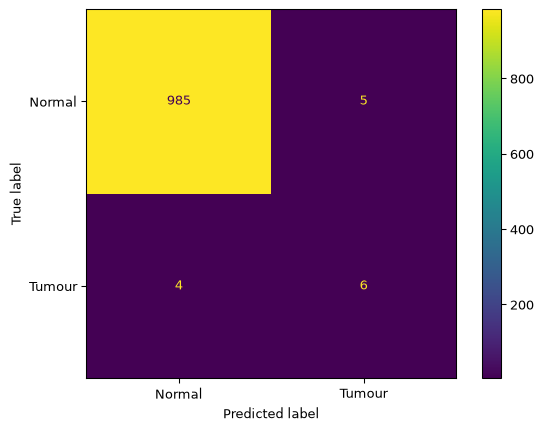

In [20]:
# Données d'exemple
y_true = ['Normal'] *  990 + ['Tumour'] *  10
y_pred = ['Normal'] *  985 + ['Tumour'] *   5 + \
         ['Normal'] *    4 + ['Tumour'] *   6

ConfusionMatrixDisplay.from_predictions(y_true, y_pred)

Considérons un ensemble de données médicales, telles que celles
impliquant des tests de diagnostic ou de l’imagerie, comprenant 990
échantillons normaux et 10 échantillons anormaux (tumeur). Cela
représente la vérité terrain.

## Mesures micro/macro (données médicales)

In [21]:
from sklearn.metrics import classification_report, recall_score

print(classification_report(y_true, y_pred), "\n")

micro_precision = precision_score(y_true, y_pred, average="micro")
macro_precision = precision_score(y_true, y_pred, average="macro")
print(f"Précision micro : {micro_precision:.2f}")
print(f"Précision macro : {macro_precision:.2f}")

print("\n")

micro_recall = recall_score(y_true, y_pred, average="micro")
macro_recall = recall_score(y_true, y_pred, average="macro")
print(f"Rappel micro : {micro_recall:.2f}")
print(f"Rappel macro : {macro_recall:.2f}")

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       990
      Tumour       0.55      0.60      0.57        10

    accuracy                           0.99      1000
   macro avg       0.77      0.80      0.78      1000
weighted avg       0.99      0.99      0.99      1000
 

Précision micro : 0.99
Précision macro : 0.77


Rappel micro : 0.99
Rappel macro : 0.80

La précision pour la classe `Tumour` est faible. Cependant, en raison de
la petite taille de l’échantillon, cela n’impacte pas significativement
la précision moyennée par micro.

# Compromis précision-rappel

## Chiffres manuscrits (revisités)

Chargement du jeu de données

In [22]:
from sklearn.datasets import fetch_openml

digits = fetch_openml('mnist_784', as_frame=False)
X, y = digits.data, digits.target

Tracé des cinq premiers exemples

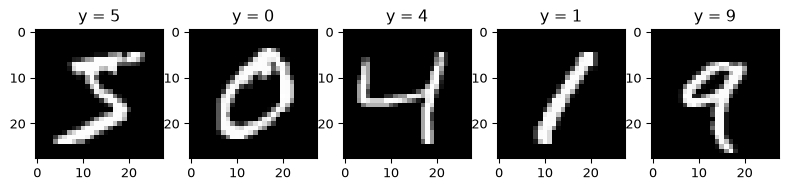

In [23]:
plt.figure(figsize=(10,2))
n = 5

for index, (image, label) in enumerate(zip(X[0:n], y[0:n])):
    plt.subplot(1, n, index + 1)
    plt.imshow(np.reshape(image, (28,28)), cmap=plt.cm.gray)
    plt.title(f'y = {label}')

Ces images ont des dimensions de $28 \times 28$ pixels.

## Tâche de classification binaire

In [24]:
# Création d'une tâche de classification binaire (un contre tous)

some_digit = X[0]
some_digit_y = y[0]

y = (y == some_digit_y)
y

array([ True, False, False, ..., False,  True, False], shape=(70000,))

. . .

In [25]:
# Création des ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.1,
    random_state=seed,
    stratify=y,
)

## `SGDClassifier`

In [26]:
from sklearn.linear_model import SGDClassifier

clf = SGDClassifier(random_state=seed)
clf.fit(X_train, y_train)

`SGDClassifier` est un classificateur linéaire entraîné par descente de
gradient stochastique. Il convient bien à ce grand jeu de données et
fournit un score continu avec `decision_function`. La régression
logistique fournit elle aussi des probabilités et des scores de décision
auxquels on peut appliquer un seuil.

## Performance

In [27]:
from sklearn.metrics import accuracy_score

y_pred = clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.9657142857142857

. . .

Le score semble élevé,

. . .

mais la distribution des classes est essentielle pour l’interpréter.

## Pas si vite

In [28]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")

dummy_clf.fit(X_train, y_train)

. . .

In [29]:
y_pred = dummy_clf.predict(X_test)

accuracy_score(y_test, y_pred)

0.9098571428571428

Le <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html"
class="external" data-icon="true">DummyClassifier</a> de scikit-learn
génère des prédictions sans tenir compte des attributs d’entrée. Avec
`strategy="most_frequent"`, il prédit toujours la classe la plus
fréquente dans les données d’entraînement et fournit ainsi une valeur de
référence simple.

Pourquoi la précision est-elle si élevée alors que ce classificateur
ignore les données d’entrée ?

La précision élevée est attribuée à la distribution des classes dans le
jeu de données. Environ 10 % des échantillons correspondent au chiffre
‘5’, qui est la classe positive dans notre tâche de classification
binaire. Par conséquent, environ 90 % des échantillons ne sont pas ‘5’
et appartiennent à la classe négative. Comme le DummyClassifier prédit
toujours la classe majoritaire, sa précision est attendue d’être autour
de 90 %.

Cela montre pourquoi l’exactitude seule ne suffit pas pour évaluer un
jeu de données déséquilibré.

## Compromis précision-rappel

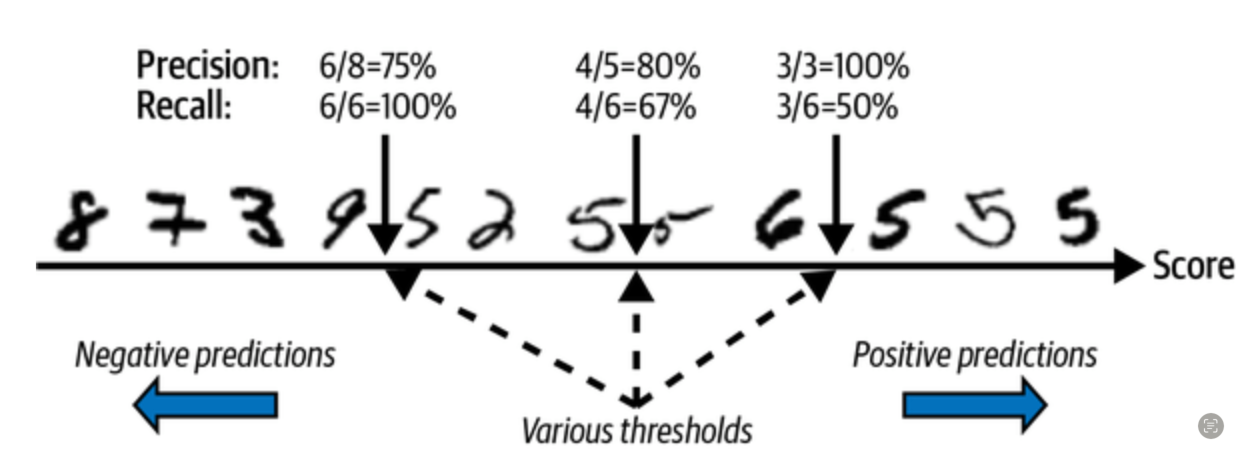

**Attribution** : Géron (2022) Figure 3.4

## Compromis précision-rappel

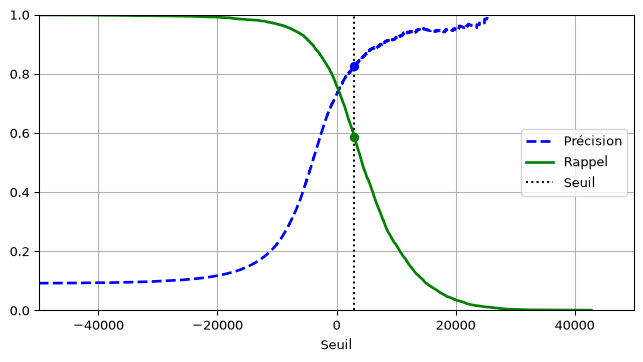

In [30]:
from sklearn.model_selection import cross_val_predict
y_scores = cross_val_predict(
    clf,
    X_train,
    y_train,
    cv=3,
    method="decision_function",
)

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(
    y_train,
    y_scores,
)

threshold = 3000

plt.figure(figsize=(8, 4))
plt.plot(
    thresholds,
    precisions[:-1],
    "b--",
    label="Précision",
    linewidth=2,
)
plt.plot(thresholds, recalls[:-1], "g-", label="Rappel", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="Seuil")

idx = (thresholds >= threshold).argmax()
plt.plot(thresholds[idx], precisions[idx], "bo")
plt.plot(thresholds[idx], recalls[idx], "go")
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Seuil")
plt.legend(loc="center right")

plt.show()

Le score continu produit par `decision_function` permet de faire varier
le seuil de décision et d’observer le compromis entre précision et
rappel. (Géron 2022) <a
href="https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb"
class="external"
data-icon="true"><code>03_classification.ipynb</code></a>.

Lorsque le seuil de décision diminue, davantage d’exemples sont prédits
comme positifs; le classificateur peut finir par étiqueter tous les
exemples comme positifs.

Inversement, lorsque le seuil augmente, moins d’exemples sont classés
comme positifs; le classificateur peut finir par ne prédire aucun
exemple positif.

Dans certaines applications, une précision élevée est essentielle. Par
exemple, si chaque prédiction doit être validée par une expérience de
laboratoire coûteuse, une entreprise pharmaceutique cherchera à examiner
d’abord les composés les plus prometteurs.

À l’inverse, lors d’un dépistage du cancer, il peut être préférable
d’abaisser le seuil et d’accepter davantage de faux positifs. Plus de
patients subiront des examens complémentaires, mais moins de cancers
risquent de passer inaperçus.

## Courbe précision-rappel

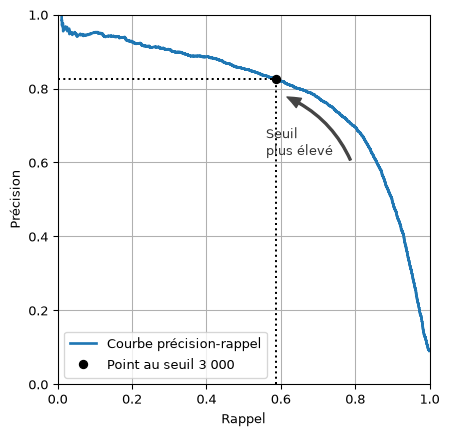

In [31]:
import matplotlib.patches as patches

plt.figure(figsize=(5, 5))

plt.plot(
    recalls,
    precisions,
    linewidth=2,
    label="Courbe précision-rappel",
)

plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot(
    [recalls[idx]],
    [precisions[idx]],
    "ko",
    label="Point au seuil 3 000",
)
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Seuil\nplus élevé", color="#333333")
plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")

plt.show()

(Géron 2022) <a
href="https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb"
class="external"
data-icon="true"><code>03_classification.ipynb</code></a>.

# Courbe ROC

## Courbe ROC

**Courbe caractéristique de fonctionnement du récepteur (ROC)**

- **Taux de vrais positifs** (TVP) en fonction du **taux de faux
  positifs** (TFP)
- Un classificateur idéal a un **TVP** proche de **1,0** et un **TFP**
  proche de **0,0**
- $\mathrm{TVP} = \frac{\mathrm{VP}}{\mathrm{VP}+\mathrm{FN}}$ (rappel,
  sensibilité)
- Le **TVP** s’approche de **un** lorsqu’il y a peu de **faux négatifs**
- $\mathrm{TFP} = \frac{\mathrm{FP}}{\mathrm{FP}+\mathrm{VN}} = 1-\mathrm{spécificité}$
- Le **TFP** s’approche de **zéro** lorsqu’il y a peu de **faux
  positifs**

Une courbe ROC représente le taux de vrais positifs en fonction du taux
de faux positifs lorsque le seuil de décision varie. Chaque seuil
produit un point de fonctionnement. Un point idéal se trouve près du
coin supérieur gauche, tandis qu’un classement aléatoire produit en
moyenne la diagonale.

La courbe résume le classement des scores pour tous les seuils, mais le
déploiement exige tout de même de choisir un seuil particulier. Les
coûts relatifs des faux positifs et des faux négatifs permettent de
déterminer le point de fonctionnement approprié. Une évaluation
un-contre-tous étend l’analyse ROC aux tâches multiclasses.

## Courbe ROC

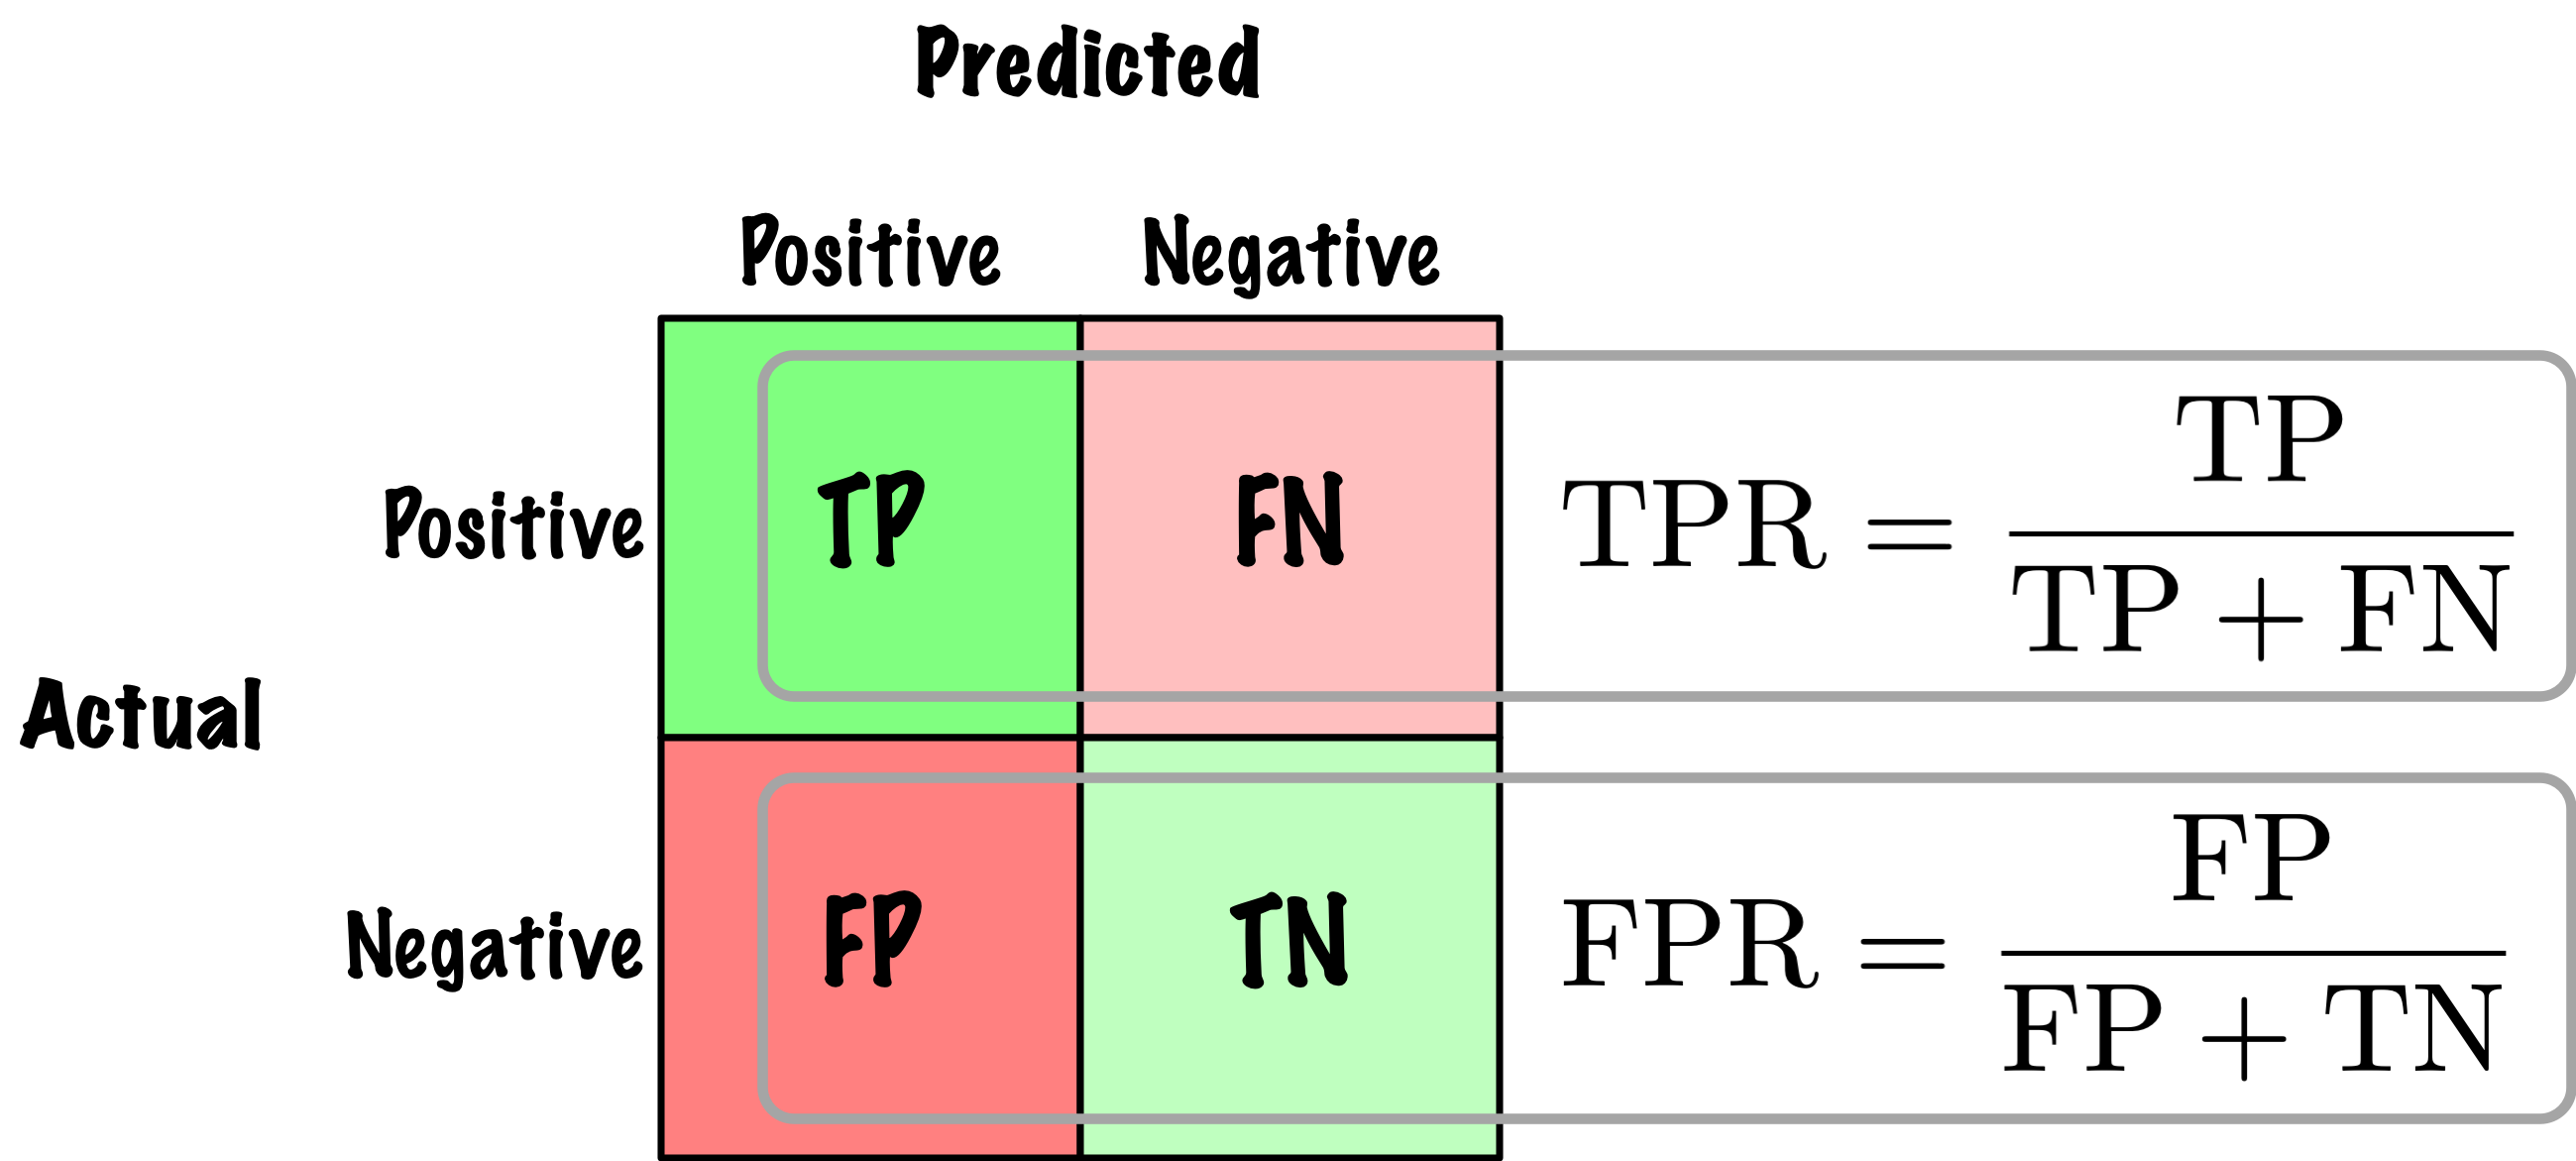

## Courbe ROC

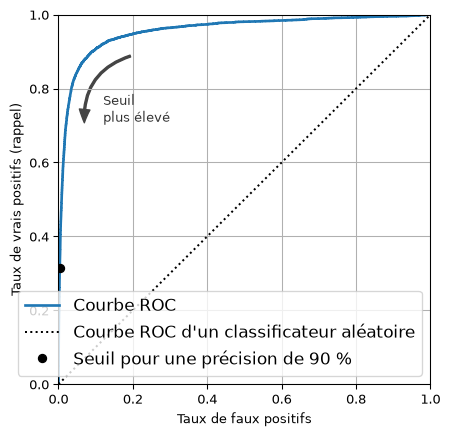

In [32]:
idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train, y_scores)

idx_for_threshold_at_90 = (
    thresholds <= threshold_for_90_precision
).argmax()
tpr_90 = tpr[idx_for_threshold_at_90]
fpr_90 = fpr[idx_for_threshold_at_90]

plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, linewidth=2, label="Courbe ROC")
plt.plot([0, 1], [0, 1], "k:", label="Courbe ROC d'un classificateur aléatoire")
plt.plot([fpr_90], [tpr_90], "ko", label="Seuil pour une précision de 90 %")

plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Seuil\nplus élevé", color="#333333")
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs (rappel)")
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)

plt.show()

**Attribution :** <a
href="https://github.com/ageron/handson-ml3/blob/main/03_classification.ipynb"
class="external"
data-icon="true"><code>03_classification.ipynb</code></a>

Le déplacement du seuil modifie à la fois le taux de vrais positifs et
le taux de faux positifs. La courbe ROC enregistre tous les points de
fonctionnement obtenus. Elle ne désigne pas à elle seule le meilleur
seuil, car ce choix dépend des coûts relatifs des faux positifs et des
faux négatifs.

## Distribution des scores et courbe ROC

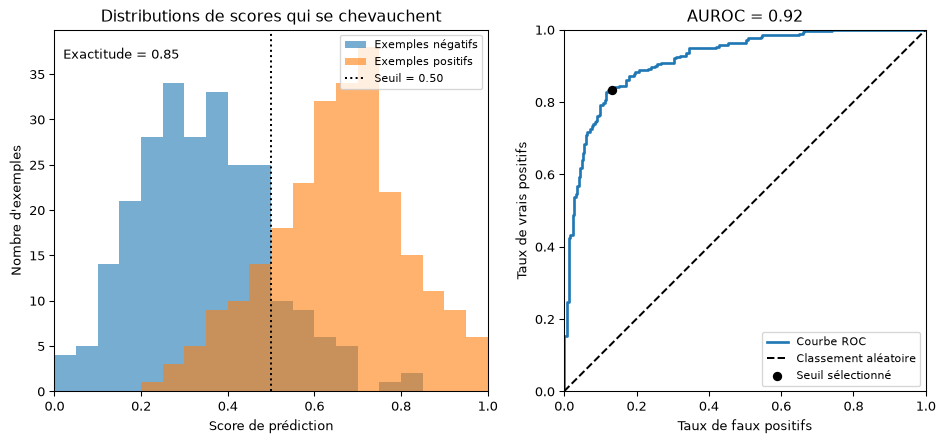

In [33]:
from sklearn.metrics import roc_auc_score, roc_curve

def plot_scores_and_roc(
    ax_scores,
    ax_roc,
    negative_scores,
    positive_scores,
    title,
    threshold=None,
):
    """Tracer les distributions des scores et leur courbe ROC."""
    labels = np.concatenate([
        np.zeros(len(negative_scores), dtype=int),
        np.ones(len(positive_scores), dtype=int),
    ])
    scores = np.concatenate([negative_scores, positive_scores])

    bins = np.linspace(0, 1, 21)
    ax_scores.hist(
        negative_scores,
        bins=bins,
        alpha=0.6,
        label="Exemples négatifs",
    )
    ax_scores.hist(
        positive_scores,
        bins=bins,
        alpha=0.6,
        label="Exemples positifs",
    )
    ax_scores.set(
        title=title,
        xlabel="Score de prédiction",
        ylabel="Nombre d'exemples",
        xlim=(0, 1),
    )

    curve_fpr, curve_tpr, _ = roc_curve(labels, scores)
    area = roc_auc_score(labels, scores)
    ax_roc.plot(curve_fpr, curve_tpr, linewidth=2, label="Courbe ROC")
    ax_roc.plot([0, 1], [0, 1], "k--", label="Classement aléatoire")
    ax_roc.set(
        title=f"AUROC = {area:.2f}",
        xlabel="Taux de faux positifs",
        ylabel="Taux de vrais positifs",
        xlim=(0, 1),
        ylim=(0, 1),
    )
    ax_roc.set_aspect("equal", adjustable="box")

    if threshold is not None:
        predictions = (scores >= threshold).astype(int)
        tn, fp, fn, tp = confusion_matrix(
            labels,
            predictions,
            labels=[0, 1],
        ).ravel()
        point_fpr = fp / (fp + tn)
        point_tpr = tp / (tp + fn)
        accuracy = np.mean(predictions == labels)

        ax_scores.axvline(
            threshold,
            color="black",
            linestyle=":",
            label=f"Seuil = {threshold:.2f}",
        )
        ax_scores.text(
            0.02,
            0.95,
            f"Exactitude = {accuracy:.2f}",
            transform=ax_scores.transAxes,
            va="top",
        )
        ax_roc.scatter(
            point_fpr,
            point_tpr,
            color="black",
            zorder=3,
            label="Seuil sélectionné",
        )

    ax_scores.legend(fontsize=8)
    ax_roc.legend(fontsize=8, loc="lower right")


roc_demo_rng = np.random.default_rng(seed)
roc_demo_size = 250
good_negative_scores = np.clip(
    roc_demo_rng.normal(0.35, 0.16, roc_demo_size),
    0,
    1,
)
good_positive_scores = np.clip(
    roc_demo_rng.normal(0.65, 0.16, roc_demo_size),
    0,
    1,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
plot_scores_and_roc(
    axes[0],
    axes[1],
    good_negative_scores,
    good_positive_scores,
    "Distributions de scores qui se chevauchent",
    threshold=0.50,
)
plt.show()

<a href="https://www.interactive-ml.com/roc-curve.html" class="external"
data-icon="true">Courbe ROC interactive</a>

L’histogramme montre les scores attribués aux exemples négatifs et
positifs. Pour le seuil indiqué, les exemples situés à sa droite sont
prédits positifs. On obtient ainsi une paire formée du taux de faux
positifs et du taux de vrais positifs, représentée par le point marqué
sur la courbe ROC.

Le déplacement du seuil modifie les étiquettes prédites, la matrice de
confusion, l’exactitude et le point de fonctionnement indiqué sur la
courbe ROC. Il ne modifie pas l’AUROC, car l’ordre des scores demeure
inchangé. Le balayage du seuil sur tous les scores observés trace la
courbe ROC complète.

La démonstration interactive liée anime ce processus et présente des
distributions de scores correspondant à des classificateurs excellents,
bons, faibles et aléatoires.

## Surface sous la courbe ROC

La **surface sous la courbe ROC (AUROC)** résume la capacité d’un score
à classer les exemples positifs au-dessus des exemples négatifs.

- $\mathrm{AUROC}=1$ : chaque exemple positif reçoit un score supérieur
  à celui de chaque exemple négatif.
- $\mathrm{AUROC}=0,5$ : classement aléatoire en moyenne.
- $\mathrm{AUROC}<0,5$ : le classement est systématiquement inversé.

L’AUROC compare des classements pour tous les seuils. Elle ne mesure pas
l’étalonnage des probabilités et ne choisit pas de seuil de
fonctionnement.

Avec la convention habituelle qui accorde un demi-point aux scores
égaux,

$$
\mathrm{AUROC}
= P(s^+ > s^-)
+ \frac{1}{2}P(s^+ = s^-),
$$

où $s^+$ et $s^-$ sont les scores d’exemples positif et négatif choisis
au hasard. Cette formulation donne à l’AUROC son interprétation
probabiliste comme mesure de classement (Hanley et McNeil 1982). Un
classificateur dont l’AUROC est inférieure à 0,5 peut tout de même
contenir de l’information utile si son classement est systématiquement
inversé.

Les courbes ROC et l’AUROC servent souvent à comparer la façon dont
plusieurs classificateurs ordonnent les mêmes exemples. Une comparaison
complète reposant sur le jeu de données sur le diabète des Indiennes
Pima est présentée en annexe.

## Classificateur parfait

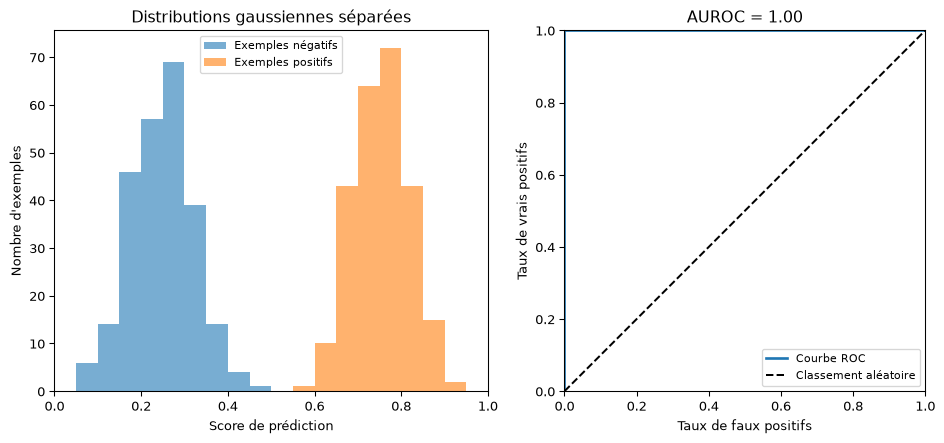

In [34]:
perfect_rng = np.random.default_rng(seed + 1)
perfect_negative_scores = np.clip(
    perfect_rng.normal(0.25, 0.07, roc_demo_size),
    0,
    1,
)
perfect_positive_scores = np.clip(
    perfect_rng.normal(0.75, 0.07, roc_demo_size),
    0,
    1,
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
plot_scores_and_roc(
    axes[0],
    axes[1],
    perfect_negative_scores,
    perfect_positive_scores,
    "Distributions gaussiennes séparées",
)
plt.show()

Les deux distributions de scores ont une forme gaussienne et ne se
chevauchent pas dans cet échantillon. Chaque exemple positif reçoit donc
un score supérieur à celui de chaque exemple négatif; l’AUROC vaut 1.

## Classificateur aléatoire

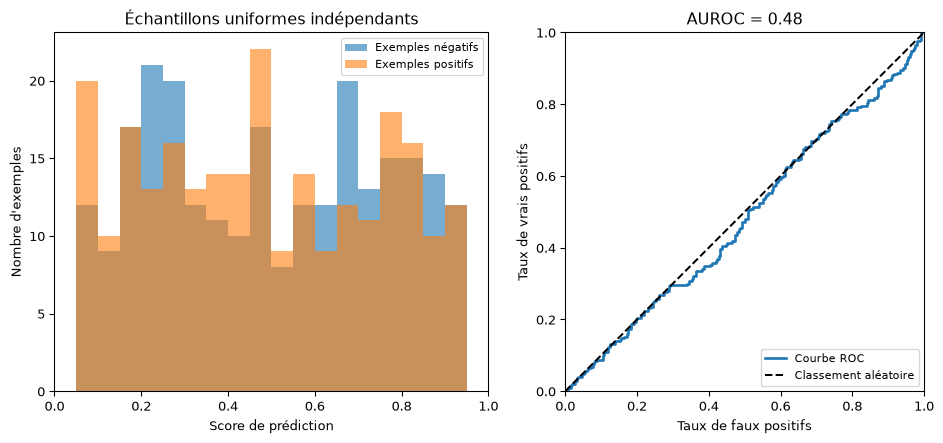

In [35]:
random_rng = np.random.default_rng(seed + 2)
random_negative_scores = random_rng.uniform(0.05, 0.95, roc_demo_size)
random_positive_scores = random_rng.uniform(0.05, 0.95, roc_demo_size)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
plot_scores_and_roc(
    axes[0],
    axes[1],
    random_negative_scores,
    random_positive_scores,
    "Échantillons uniformes indépendants",
)
plt.show()

Les scores des deux classes sont tirés indépendamment de la même
distribution uniforme. Leurs histogrammes empiriques diffèrent en raison
de la variation d’échantillonnage, mais aucune classe ne tend à recevoir
des scores plus élevés. L’AUROC est donc proche de 0,5 et la courbe ROC
empirique fluctue autour de la diagonale aléatoire.

La règle « tout positif » est obtenue lorsque le seuil se situe sous
tous les scores et correspond au point ROC $(1,1)$. La règle « tout
négatif » correspond à $(0,0)$. Ce sont des points de fonctionnement
produits par des seuils extrêmes, tandis que la diagonale représente un
classement aléatoire pour l’ensemble des seuils.

## AUROC inférieure à 0,5

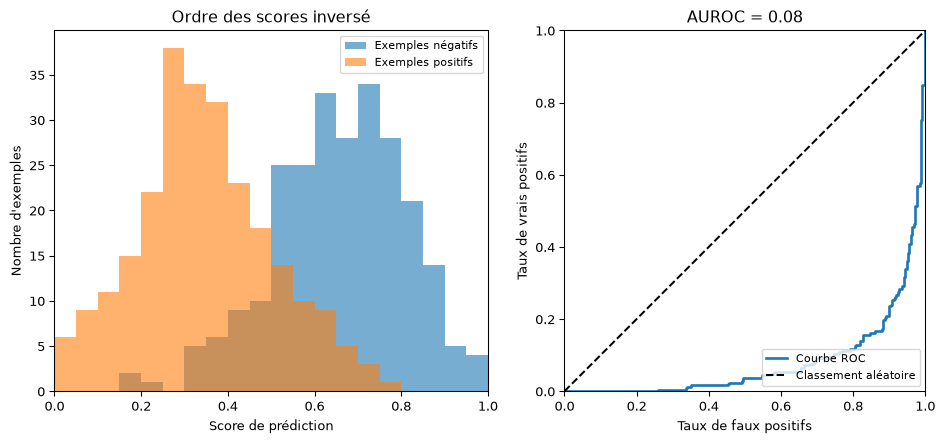

In [36]:
reversed_negative_scores = 1 - good_negative_scores
reversed_positive_scores = 1 - good_positive_scores

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), constrained_layout=True)
plot_scores_and_roc(
    axes[0],
    axes[1],
    reversed_negative_scores,
    reversed_positive_scores,
    "Ordre des scores inversé",
)
plt.show()

Avant d’examiner la figure, imaginez l’apparence que devraient avoir les
histogrammes lorsque l’AUROC est inférieure à 0,5.

Les exemples positifs doivent tendre à recevoir des scores plus faibles
que les exemples négatifs. Le classement est donc systématiquement
inversé et la courbe ROC se situe sous la diagonale aléatoire. Inverser
la direction des scores transforme une AUROC de $a$ en $1-a$, hormis le
traitement des égalités.

## ROC ou précision-rappel?

- La courbe ROC utilise le **rappel** et le **taux de faux positifs**,
  dont le dénominateur contient tous les exemples négatifs.
- Lorsque la classe positive est très rare, un grand nombre de vrais
  négatifs peut rendre le taux de faux positifs faible, même si
  plusieurs prédictions positives sont erronées.
- Une courbe précision-rappel se concentre sur la classe positive et
  montre quelle proportion des prédictions positives est correcte.

Utilisez la courbe qui correspond au problème de décision et examinez
toujours la prévalence des classes ainsi qu’un seuil de fonctionnement.

Les courbes ROC demeurent valides avec des données déséquilibrées, mais
leur interprétation visuelle peut paraître optimiste lorsque la classe
négative est beaucoup plus grande que la classe positive. Les courbes
précision-rappel communiquent souvent plus directement la performance
sur une classe positive rare, car la précision réagit au nombre de
prédictions faussement positives (Davis et Goadrich 2006).

# Construction de la courbe ROC et calcul de l’AUROC

## Régression logistique

- **Modèle** :

  $$
  h_\theta(x_i) = \sigma(\theta_0 + x_i^\top\theta)
  = \frac{1}{1+e^{-(\theta_0+x_i^\top\theta)}}
  $$

- **Prédiction** :

  - Attribuer $y_i = 0$ si $h_\theta(x_i) < 0,5$.
  - Attribuer $y_i = 1$ si $h_\theta(x_i) \geq 0,5$.

- **Fonction de perte** : entropie croisée

$$
J(\theta) = -\frac{1}{N} \sum_{i=1}^{N}
\left[
y_i \log h_\theta(x_i)
+ (1-y_i) \log\left(1-h_\theta(x_i)\right)
\right]
$$

Les décomptes de la matrice de confusion évoluent systématiquement
lorsque le seuil de décision passe de 0 à 1.

Au seuil 0

- Tous les exemples sont prédits positifs.
- Tous les positifs réels sont vrais positifs et tous les négatifs réels
  sont faux positifs.
- $\text{TVP}=1$, $\text{TFP}=1$ et le point ROC est $(1,1)$.

Lorsque le seuil augmente de 0 à 1

- Moins d’exemples sont prédits positifs.
- Les nombres de vrais positifs et de faux positifs diminuent.
- Le TVP et le TFP diminuent de façon monotone.
- La courbe se déplace vers le bas et la gauche dans l’espace ROC.

Au seuil 1

- Tous les exemples sont prédits négatifs.
- VP = 0, FP = 0.
- $\text{TVP}=0$, $\text{TFP}=0$ et le point ROC est $(0,0)$.

En résumé, un seuil plus faible produit davantage de prédictions
positives; les VP, FP, TVP et TFP augmentent. Un seuil plus élevé
produit davantage de prédictions négatives; ces quantités diminuent. La
forme de la courbe dépend de la capacité du modèle à séparer les deux
classes : un modèle parfait monte immédiatement vers $(0,1)$, un
classement aléatoire suit en moyenne la diagonale et un classement
systématiquement inversé se situe sous celle-ci.

## Mise en œuvre : régression logistique

Cette mise en œuvre a été présentée au cours 6. Elle est reprise ici
afin que le carnet contienne un modèle fonctionnel permettant de
construire la courbe ROC et de calculer l’AUROC.

In [37]:
import numpy as np

class LogisticRegression:

    """
    Régression logistique binaire entraînée par descente de gradient par lot.

    Paramètres
    ----------
    learning_rate : float, default=0.1
        Pas de la descente de gradient.
    max_iter : int, default=1000
        Nombre d'itérations de la descente de gradient.
    Remarques
    ---------
    - Cette mise en œuvre attend des étiquettes binaires {0, 1}.
    - L'ordonnée à l'origine est ajoutée pendant `fit`.
    - Par souci de simplicité, il n'y a ni régularisation ni arrêt précoce.
    """

    def __init__(
        self,
        learning_rate: float = 0.1,
        max_iter: int = 1000,
    ):
        if learning_rate <= 0:
            raise ValueError("learning_rate doit être positif.")
        if max_iter <= 0:
            raise ValueError("max_iter doit être positif.")

        self.learning_rate = learning_rate
        self.max_iter = max_iter

        # Attributs définis après l'ajustement
        self._theta = None
        self._loss_history = None
        self._n_features = None
        self._fitted = False

    def fit(self, X: np.ndarray, y: np.ndarray) -> "LogisticRegression":
        """Ajuster les paramètres du modèle par descente de gradient."""
        X = self._as_2d_array(X, name="X")
        y = self._as_1d_array(y, name="y")

        if X.shape[0] != y.shape[0]:
            raise ValueError(
                "X et y doivent contenir le même nombre d'exemples."
            )
        self._check_binary_labels(y)

        n_examples, n_features = X.shape
        self._n_features = n_features
        Xb = self._add_intercept(X)

        # Une initialisation à zéro suffit puisque l'objectif est convexe.
        self._theta = np.zeros(n_features + 1, dtype=float)
        self._loss_history = []

        for _ in range(self.max_iter):
            probabilities = self._sigmoid(Xb @ self._theta)
            gradient = (Xb.T @ (probabilities - y)) / n_examples
            self._theta -= self.learning_rate * gradient

            updated_probabilities = self._sigmoid(Xb @ self._theta)
            self._loss_history.append(
                self._bce_loss(updated_probabilities, y)
            )

        self._fitted = True
        return self

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Retourner les probabilités prédites de la classe positive."""
        self._ensure_fitted()
        X = self._as_2d_array(X, name="X")
        self._ensure_same_n_features(X)

        Xb = self._add_intercept(X)
        return self._sigmoid(Xb @ self._theta)

    def predict(
        self,
        X: np.ndarray,
        threshold: float = 0.5,
    ) -> np.ndarray:
        """Retourner les classes prédites selon un seuil de probabilité."""
        if not 0 <= threshold <= 1:
            raise ValueError("threshold doit être compris entre 0 et 1.")
        return (self.predict_proba(X) >= threshold).astype(int)

    @property
    def intercept_(self) -> float:
        """Retourner l'ordonnée à l'origine ajustée."""
        self._ensure_fitted()
        return float(self._theta[0])

    @property
    def coef_(self) -> np.ndarray:
        """Retourner une copie des coefficients ajustés."""
        self._ensure_fitted()
        return self._theta[1:].copy()

    def get_loss_history(self) -> list:
        """Retourner une copie des pertes recueillies pendant l'ajustement."""
        self._ensure_fitted()
        return list(self._loss_history)

    @staticmethod
    def _sigmoid(z: np.ndarray) -> np.ndarray:
        """Calculer la sigmoïde sans débordement numérique."""
        z = np.asarray(z, dtype=float)
        result = np.empty_like(z)
        positive = z >= 0
        result[positive] = 1.0 / (1.0 + np.exp(-z[positive]))
        exp_z = np.exp(z[~positive])
        result[~positive] = exp_z / (1.0 + exp_z)
        return result

    @staticmethod
    def _bce_loss(probabilities: np.ndarray, y: np.ndarray) -> float:
        probabilities = np.clip(probabilities, 1e-12, 1.0 - 1e-12)
        return float(
            -np.mean(
                y * np.log(probabilities)
                + (1 - y) * np.log(1 - probabilities)
            )
        )

    @staticmethod
    def _as_2d_array(X, name="X") -> np.ndarray:
        X = np.asarray(X, dtype=float)
        if X.ndim != 2:
            message = (
                f"{name} doit être un tableau 2D de forme "
                "(n_samples, n_features)."
            )
            raise ValueError(message)
        return X

    @staticmethod
    def _as_1d_array(y, name="y") -> np.ndarray:
        y = np.asarray(y, dtype=float)
        if y.ndim != 1:
            message = f"{name} doit avoir la forme (n_samples,)."
            raise ValueError(message)
        return y

    @staticmethod
    def _check_binary_labels(y: np.ndarray) -> None:
        if not np.array_equal(np.unique(y), np.array([0.0, 1.0])):
            raise ValueError(
                "y doit contenir les deux étiquettes binaires 0 et 1."
            )

    @staticmethod
    def _add_intercept(X: np.ndarray) -> np.ndarray:
        return np.column_stack([np.ones(X.shape[0]), X])

    def _ensure_fitted(self) -> None:
        if not self._fitted or self._theta is None:
            raise RuntimeError(
                "Appelez fit(X, y) avant d'utiliser le modèle ajusté."
            )

    def _ensure_same_n_features(self, X: np.ndarray) -> None:
        if X.shape[1] != self._n_features:
            message = (
                f"X contient {X.shape[1]} attributs; "
                f"{self._n_features} étaient attendus."
            )
            raise ValueError(message)

## Mise en œuvre : courbe ROC

In [38]:
def compute_roc_curve(y_true, y_scores):
    y_true = np.asarray(y_true)
    y_scores = np.asarray(y_scores, dtype=float)
    thresholds = np.r_[np.inf, np.sort(np.unique(y_scores))[::-1]]
    tpr_list, fpr_list = [], []

    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        tn = np.sum((y_true == 0) & (y_pred == 0))

        tpr_list.append(tp / (tp + fn))  # taux de vrais positifs
        fpr_list.append(fp / (fp + tn))  # taux de faux positifs

    return np.array(fpr_list), np.array(tpr_list), thresholds

## Mise en œuvre : AUROC

In [39]:
def compute_auroc(fpr, tpr):

    return np.trapezoid(tpr, fpr)

La **règle des trapèzes** approxime une intégrale en divisant la région
sous une courbe en trapèzes. Elle calcule ici l’aire sous la courbe ROC
linéaire par morceaux.

## Exemple : générer les données et les prédictions

In [40]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=1000,
    n_features=2,
    centers=2,
    cluster_std=5,
    random_state=seed,
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=seed,
    stratify=y,
)

model = LogisticRegression(learning_rate=0.1, max_iter=500)
model.fit(X_train, y_train)

## Exemple : tracer

AUROC manuelle :      0.938
AUROC scikit-learn :  0.938

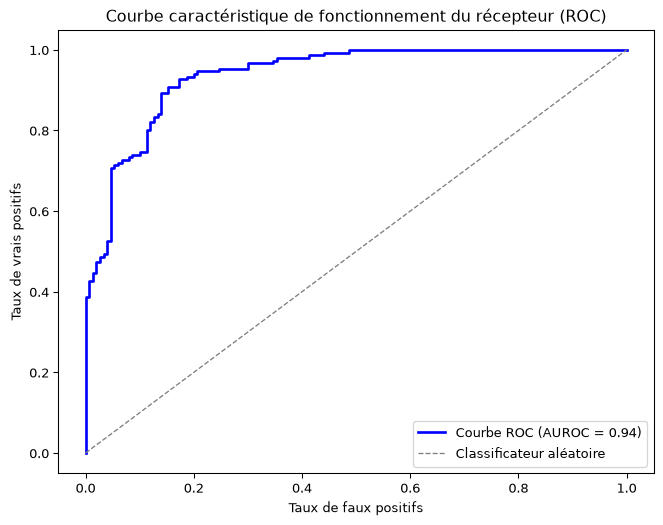

In [41]:
# Calculer les probabilités prédites de la classe positive sur l'ensemble de test
y_probs = model.predict_proba(X_test)

# Calculer la courbe ROC (TFP et TVP pour chaque seuil)
fpr, tpr, thresholds = compute_roc_curve(y_test, y_probs)
auroc_value = compute_auroc(fpr, tpr)

from sklearn.metrics import roc_auc_score
sklearn_auroc = roc_auc_score(y_test, y_probs)

print(f"AUROC manuelle :      {auroc_value:.3f}")
print(f"AUROC scikit-learn :  {sklearn_auroc:.3f}")

# Tracer la courbe ROC
plt.figure(figsize=(8, 6))
plt.plot(
    fpr,
    tpr,
    color="blue",
    lw=2,
    label=f"Courbe ROC (AUROC = {auroc_value:.2f})",
)
plt.plot(
    [0, 1],
    [0, 1],
    color="gray",
    lw=1,
    linestyle="--",
    label="Classificateur aléatoire",
)
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe caractéristique de fonctionnement du récepteur (ROC)")
plt.legend(loc="lower right")
plt.show()

## Voir aussi

- <a
  href="https://scikit-learn.org/stable/auto_examples/model_selection/plot_roc.html"
  class="external" data-icon="true">Courbe ROC multiclasse</a> présente
  des exemples de courbes moyennes micro et macro.

------------------------------------------------------------------------

<https://youtu.be/4jRBRDbJemM>

La vidéo ci-dessus de StatQuest, présentée par Josh Starmer, explique
pas à pas comment construire et analyser les courbes ROC.

# Conclusion

## Résumé

- Dérivé les décomptes binaires et un-contre-tous à partir de **matrices
  de confusion**.
- Calculé et interprété l’**exactitude**, la **précision**, le
  **rappel** et le **score $F_1$**, y compris les limites de
  l’exactitude en présence d’un déséquilibre des classes.
- Distingué la **moyenne micro**, qui accorde le même poids à chaque
  prédiction, de la **moyenne macro**, qui accorde le même poids à
  chaque classe.
- Relié le seuil de décision au **compromis précision-rappel** et aux
  points de fonctionnement de la **courbe ROC**.
- Interprété l’**AUROC** comme une mesure du classement produit par les
  scores. L’AUROC n’évalue pas l’étalonnage des probabilités et ne
  sélectionne pas de seuil de décision.

## Références principales

- Sokolova et Lapalme (2009) analyse systématiquement les mesures de
  performance pour les tâches de classification binaire, multiclasse et
  multiétiquette.
- Hanley et McNeil (1982) établit l’interprétation probabiliste de la
  surface sous une courbe ROC.
- Davis et Goadrich (2006) explique la relation entre les courbes ROC et
  précision-rappel, y compris l’effet d’une distribution déséquilibrée
  des classes.

## Évaluation des algorithmes d’apprentissage

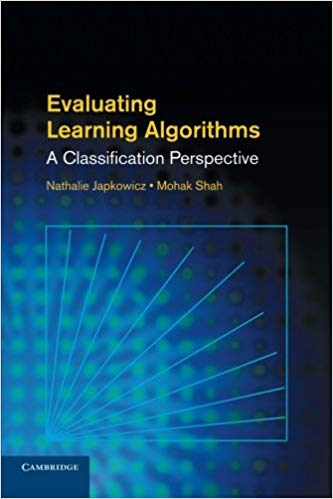

- Ce <a
  href="https://www.cambridge.org/core/books/evaluating-learning-algorithms/3CB22D16AB609D1770C24CA2CB5A11BF"
  class="external" data-icon="true">livre</a> examine le processus
  d’évaluation, en accordant une attention particulière aux algorithmes
  de classification (Japkowicz et Shah 2011).

- <a href="https://www.american.edu/cas/faculty/japkowic.cfm"
  class="external" data-icon="true">Nathalie Japkowicz</a> a été
  professeure à l’Université d’Ottawa.

- <a href="http://www.mohakshah.com" class="external"
  data-icon="true">Mohak Shah</a> a obtenu son doctorat à l’Université
  d’Ottawa et a occupé plusieurs postes dans l’industrie en intelligence
  artificielle et en apprentissage automatique.

## Prochain cours

- Nous examinerons la validation croisée et le réglage des
  hyperparamètres.

## Références

Davis, Jesse, et Mark Goadrich. 2006. « The relationship between
Precision-Recall and ROC curves ». *Proceedings of the 23rd
international conference on Machine learning - ICML ’06*, 233‑40.
<https://doi.org/10.1145/1143844.1143874>.

Géron, Aurélien. 2022. *Hands-on Machine Learning with Scikit-Learn,
Keras, and TensorFlow*. 3ᵉ éd. O’Reilly Media, Inc.

Hanley, J A, et B J McNeil. 1982. « The meaning and use of the area
under a receiver operating characteristic (ROC) curve. » *Radiology* 143
(1): 29‑36. <https://doi.org/10.1148/radiology.143.1.7063747>.

Japkowicz, Nathalie, et Mohak Shah. 2011. *Evaluating Learning
Algorithms: a classification perspective*. Cambridge University Press.

Knowler, William C., David J. Pettitt, Peter J. Savage, et Peter H.
Bennett. 1981. « Diabetes incidence in Pima indians: contributions of
obesity and parental diabetes. » *American journal of epidemiology* 113
2: 144‑56. <https://api.semanticscholar.org/CorpusID:25209675>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

Sokolova, Marina, et Guy Lapalme. 2009. « A systematic analysis of
performance measures for classification tasks ». *Information Processing
and Management* 45 (4): 427‑37.
<https://doi.org/10.1016/j.ipm.2009.03.002>.

Unceta, Irene, Paula Subı́as-Beltrán, et Oriol Pujol. 2026. « The
epistemic debt of generative AI ». *Nature Machine Intelligence* 8 (9):
1328‑30. <https://doi.org/10.1038/s42256-026-01294-w>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa

# Annexe : 20 Newsgroups

## Exemple complet : 20 Newsgroups

Nous utilisons le <a
href="https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html#sklearn.datasets.fetch_20newsgroups"
class="external" data-icon="true">jeu de données textuelles 20
Newsgroups</a> de <a href="https://scikit-learn.org" class="external"
data-icon="true">scikit-learn</a>.

Le jeu complet contient environ 18 000 messages provenant de 20 groupes
de discussion. Cet exemple utilise quatre sujets.

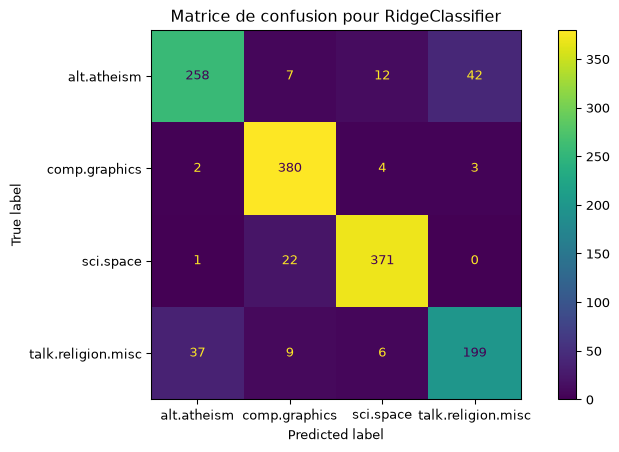

In [42]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeClassifier

categories = [
    "alt.atheism",
    "talk.religion.misc",
    "comp.graphics",
    "sci.space",
]

data_train = fetch_20newsgroups(
    subset="train",
    categories=categories,
    shuffle=True,
    random_state=seed,
)
data_test = fetch_20newsgroups(
    subset="test",
    categories=categories,
    shuffle=True,
    random_state=seed,
)

vectorizer = TfidfVectorizer(
    sublinear_tf=True,
    max_df=0.5,
    min_df=5,
    stop_words="english",
)
X_train = vectorizer.fit_transform(data_train.data)
X_test = vectorizer.transform(data_test.data)
y_train = data_train.target
y_test = data_test.target
target_names = data_train.target_names

clf = RidgeClassifier(tol=1e-2, solver="sparse_cg")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

fig, ax = plt.subplots(figsize=(10, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
ax.xaxis.set_ticklabels(target_names)
ax.yaxis.set_ticklabels(target_names)
ax.set_title(f"Matrice de confusion pour {clf.__class__.__name__}")
plt.show()

## Matrice de confusion sous forme de tableau

In [43]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[258,   7,  12,  42],
       [  2, 380,   4,   3],
       [  1,  22, 371,   0],
       [ 37,   9,   6, 199]])

## Décomptes un-contre-tous

In [44]:
def true_positive(cm, i):
    return cm[i, i]

def false_positive(cm, i):
    return np.sum(cm[:, i]) - cm[i, i]

def false_negative(cm, i):
    return np.sum(cm[i, :]) - cm[i, i]

def true_negative(cm, i):
    n_examples = cm.sum()
    tp = true_positive(cm, i)
    fp = false_positive(cm, i)
    fn = false_negative(cm, i)
    return n_examples - (tp + fp + fn)

## Précision micro et macro

In [45]:
def precision_micro(cm):
    _, n_classes = cm.shape
    tp = fp = 0
    for i in range(n_classes):
        tp += true_positive(cm, i)
        fp += false_positive(cm, i)
    return tp / (tp + fp)

def precision_macro(cm):
    _, n_classes = cm.shape
    precision_sum = 0
    for i in range(n_classes):
        tp = true_positive(cm, i)
        fp = false_positive(cm, i)
        precision_sum += tp / (tp + fp)
    return precision_sum / n_classes

print(f"Précision micro : {precision_micro(cm):.3f}")
print(f"Précision macro : {precision_macro(cm):.3f}")

Précision micro : 0.893
Précision macro : 0.884

## Précision moyenne micro

$$
  \frac{(258+380+371+199)}{(258+380+371+199)+(40+38+22+45)}
$$ où

- 40 = 2 + 1 + 37
- 38 = 7 + 22 + 9
- 22 = 12 + 4 + 6
- 45 = 42 + 3 + 0

89,28307465 %

## Précision moyenne macro

- $\mathrm{Précision}_0 = \frac{258}{258+(2+1+37)} = 0,8657718121$
- $\mathrm{Précision}_1 = \frac{380}{380+(7+22+9)} = 0,9090909091$
- $\mathrm{Précision}_2 = \frac{371}{371+(12+4+6)} = 0,9440203562$
- $\mathrm{Précision}_3 = \frac{199}{199+(42+3+0)} = 0,8155737705$

$\mathrm{Précision}_{\mathrm{macro}} = \frac{0,8657718121 + 0,9090909091 + 0,9440203562 + 0,8155737705}{4}$

88,3614212 %

## Rappel micro et macro

In [46]:
def recall_micro(cm):
    _, n_classes = cm.shape
    tp = fn = 0
    for i in range(n_classes):
        tp += true_positive(cm, i)
        fn += false_negative(cm, i)
    return tp / (tp + fn)

def recall_macro(cm):
    _, n_classes = cm.shape
    recall_sum = 0
    for i in range(n_classes):
        tp = true_positive(cm, i)
        fn = false_negative(cm, i)
        recall_sum += tp / (tp + fn)
    return recall_sum / n_classes

print(f"Rappel micro : {recall_micro(cm):.3f}")
print(f"Rappel macro : {recall_macro(cm):.3f}")

Rappel micro : 0.893
Rappel macro : 0.880

# Annexe : comparaison des scores de classificateurs

## Jeu de données OpenML

>  **<a href="https://www.openml.org" class="external"
> data-icon="true">www.openml.org</a>**
>
> OpenML est une plateforme ouverte de partage de jeux de données,
> d’algorithmes et d’expériences qui favorise la reproductibilité en
> apprentissage automatique.

. . .

In [47]:
diabetes = fetch_openml(name="diabetes", version=1)
print(diabetes.DESCR)

Le jeu de données sur le diabète des Indiennes Pima contient 768
exemples et huit attributs numériques. Il permet une démonstration
compacte de l’évaluation fondée sur les scores, mais son âge, sa
population et ses limites de qualité doivent être pris en compte avant
d’en tirer des conclusions médicales.

## Jeu de données sur le diabète des Indiennes Pima

In [48]:
# Charger le jeu de données sur le diabète des Indiennes Pima
pima = fetch_openml(data_id=37, as_frame=True)

# Extraire les attributs et la cible
X = pima.data
y = pima.target

# Encoder les deux étiquettes cibles avec 0 et 1
y = y.map({"tested_negative": 0, "tested_positive": 1})

# Diviser le jeu de données
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=seed,
    stratify=y,
)

<a
href="https://www.openml.org/search?type=data&amp;sort=version&amp;status=any&amp;order=asc&amp;exact_name=diabetes&amp;id=37"
class="external" data-icon="true">Pima Indians Diabetes Dataset</a>,
décrit dans Knowler et al. (1981)
\[<a href="https://pubmed.ncbi.nlm.nih.gov/7468572/" class="external"
data-icon="true">PubMed</a>\].

## Comparaison de plusieurs classificateurs

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Comparaison de plusieurs classificateurs

In [50]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

dt = DecisionTreeClassifier(random_state=seed)
dt.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=seed)
rf.fit(X_train, y_train)

Les deux classificateurs fondés sur les distances ou le gradient
utilisent des attributs standardisés. Les classificateurs fondés sur les
arbres utilisent les valeurs originales.

## Courbes ROC et AUROC

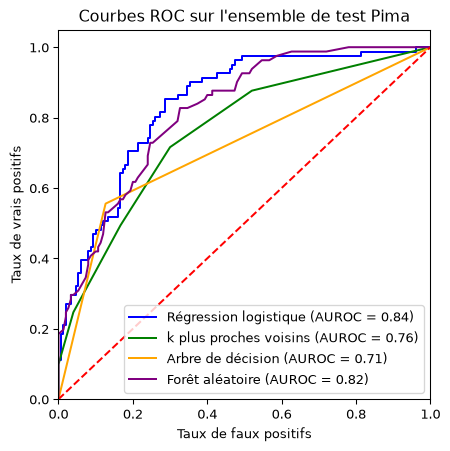

In [51]:
from sklearn.metrics import roc_auc_score

y_pred_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]
y_pred_prob_dt = dt.predict_proba(X_test)[:, 1]
y_pred_prob_rf = rf.predict_proba(X_test)[:, 1]

# Calculer les courbes ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_pred_prob_knn)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_prob_rf)

# Calculer les valeurs d'AUROC
auroc_lr = roc_auc_score(y_test, y_pred_prob_lr)
auroc_knn = roc_auc_score(y_test, y_pred_prob_knn)
auroc_dt = roc_auc_score(y_test, y_pred_prob_dt)
auroc_rf = roc_auc_score(y_test, y_pred_prob_rf)

# Tracer les courbes ROC
plt.figure(figsize=(5, 5))
plt.plot(
    fpr_lr,
    tpr_lr,
    color="blue",
    label=f"Régression logistique (AUROC = {auroc_lr:.2f})",
)
plt.plot(
    fpr_knn,
    tpr_knn,
    color="green",
    label=f"k plus proches voisins (AUROC = {auroc_knn:.2f})",
)
plt.plot(
    fpr_dt,
    tpr_dt,
    color="orange",
    label=f"Arbre de décision (AUROC = {auroc_dt:.2f})",
)
plt.plot(
    fpr_rf,
    tpr_rf,
    color="purple",
    label=f"Forêt aléatoire (AUROC = {auroc_rf:.2f})",
)
plt.plot([0, 1], [0, 1], color="red", linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbes ROC sur l'ensemble de test Pima")
plt.legend(loc="lower right")
plt.show()

Les courbes ROC représentent la performance d’un classificateur pour
**tous les seuils possibles**. En traçant le taux de vrais positifs en
fonction du taux de faux positifs, elles révèlent le compromis entre la
sensibilité (rappel) et la spécificité.

Contrairement à l’exactitude, une courbe ROC résume le classement
produit par les scores pour plusieurs seuils. Cet exemple complet décrit
les modèles ajustés sur un seul ensemble de test tenu à l’écart. Il ne
constitue pas une procédure de sélection de modèle. Le cours 8 distingue
la validation de l’évaluation finale.